# FUNWAVE capstone report-support notebook

This notebook is designed to performe **report-ready analysis** after the main modeling notebook is done.

It works in two modes:

1. **Preferred mode:** load the saved CSV/model/figure artifacts from the existing `funwave_capstone_station_artifacts` folder.
2. **Fallback mode:** if those artifact files are not available in the current session, extract the recoverable tables, logs, and figures embedded inside the saved-output notebook, `funwave_capstone_station_fullsequence_pipeline_v2.ipynb`.

All new outputs are written to a separate folder so it does not overwrite the original run artifacts:

- `funwave_capstone_report_support_outputs/tables`
- `funwave_capstone_report_support_outputs/figures`
- `funwave_capstone_report_support_outputs/notes`


In [1]:
# =========================
# User configuration
# =========================
from pathlib import Path

# The already-finished notebook with saved outputs if needed.
SOURCE_NOTEBOOK = Path("funwave_capstone_station_fullsequence_pipeline_v2.ipynb")

# Leave as None to auto-detect the original artifact folder.
# Typical value: Path("./funwave_capstone_station_artifacts")
USER_ARTIFACT_ROOT = None

# Leave as None to create ./funwave_capstone_report_support_outputs
USER_OUTPUT_ROOT = None

# Optional: try to read saved model bundles to count parameters.
USE_MODEL_BUNDLES_FOR_PARAM_COUNTS = True


In [2]:
# =========================
# Imports and helper utilities
# =========================
import os
import io
import re
import json
import math
import base64
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import torch
except Exception:
    torch = None

try:
    import joblib
except Exception:
    joblib = None

from IPython.display import display, Markdown

plt.rcParams["figure.dpi"] = 120

def join_text(value):
    if value is None:
        return ""
    if isinstance(value, list):
        return "".join(str(x) for x in value)
    return str(value)

def read_ipynb(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def stream_text(nb, cell_idx):
    cell = nb["cells"][cell_idx]
    parts = []
    for out in cell.get("outputs", []):
        if out.get("output_type") == "stream":
            parts.append(join_text(out.get("text", "")))
    return "".join(parts)

def html_tables_from_cell(nb, cell_idx):
    tables = []
    cell = nb["cells"][cell_idx]
    for out in cell.get("outputs", []):
        data = out.get("data", {})
        if "text/html" in data:
            html = join_text(data["text/html"])
            try:
                dfs = pd.read_html(io.StringIO(html))
                tables.extend(dfs)
            except Exception:
                pass
    return tables

def flatten_columns(df):
    if df is None:
        return None
    out = df.copy()
    cols = []
    for c in out.columns:
        if isinstance(c, tuple):
            cols.append("_".join([str(x) for x in c if str(x) != ""]).strip("_"))
        else:
            cols.append(str(c))
    out.columns = cols
    return out

def clean_dataframe(df):
    if df is None:
        return None
    out = flatten_columns(df).copy()
    drop_cols = [c for c in out.columns if str(c).startswith("Unnamed:")]
    if len(drop_cols):
        out = out.drop(columns=drop_cols)
    return out

def maybe_numeric(series):
    return pd.to_numeric(series, errors="ignore")

def parse_config_from_ready_notebook(nb):
    txt = stream_text(nb, 4)
    data_root_match = re.search(r"DATA_ROOT:\s*(.*?)\n", txt)
    artifact_root_match = re.search(r"ARTIFACT_ROOT:\s*(.*?)\n", txt)
    json_match = re.search(r"(\{.*\})", txt, re.S)

    data_root = data_root_match.group(1).strip() if data_root_match else None
    artifact_root = artifact_root_match.group(1).strip() if artifact_root_match else None
    cfg = json.loads(json_match.group(1)) if json_match else {}
    return cfg, data_root, artifact_root

def parse_counts_from_text(text):
    patterns = {
        "discovered_nc_files": r"Discovered \.nc files:\s*([0-9]+)",
        "valid_files": r"Valid files:\s*([0-9]+)",
        "selected_runs": r"Selected runs for this notebook:\s*([0-9]+)",
        "processed_run_caches": r"Processed run caches:\s*([0-9]+)",
        "total_station_samples": r"Total station samples:\s*([0-9]+)",
        "failed_runs": r"Failed runs:\s*([0-9]+)",
        "train_samples": r"Train samples:\s*([0-9]+)",
        "train_unique_runs": r"Train samples:\s*[0-9]+\s*\|\s*unique runs:\s*([0-9]+)",
        "val_samples": r"Val samples:\s*([0-9]+)",
        "val_unique_runs": r"Val samples:\s*[0-9]+\s*\|\s*unique runs:\s*([0-9]+)",
        "test_samples": r"Test samples:\s*([0-9]+)",
        "test_unique_runs": r"Test samples:\s*[0-9]+\s*\|\s*unique runs:\s*([0-9]+)",
        "cache_size_gb": r"Processed cache size \(GB\):\s*([0-9.]+)",
        "available_ram_gb": r"Available RAM \(GB\):\s*([0-9.]+)",
        "stage1_best_alpha": r"Stage 1 best alpha:\s*([0-9.eE+-]+)",
        "stage1_val_mse": r"Stage 1 val MSE \(coefficient space\):\s*([0-9.eE+-]+)",
    }
    out = {}
    for key, pat in patterns.items():
        m = re.search(pat, text)
        if m:
            val = m.group(1)
            if "." in val or "e" in val.lower():
                out[key] = float(val)
            else:
                out[key] = int(val)
    return out

def parse_training_history(nb, cell_idx, stage_label):
    txt = stream_text(nb, cell_idx)
    pat = re.compile(
        rf"\[{re.escape(stage_label)}\]\s+epoch\s+(\d+)\s+\|\s+train=([0-9.]+)\s+\|\s+val=([0-9.]+)"
    )
    rows = [
        {"epoch": int(epoch), "train_total": float(train), "val_total": float(val)}
        for epoch, train, val in pat.findall(txt)
    ]
    return pd.DataFrame(rows)

def extract_embedded_png(nb, cell_idx, display_order=0):
    cell = nb["cells"][cell_idx]
    seen = -1
    for out in cell.get("outputs", []):
        if out.get("output_type") == "display_data":
            data = out.get("data", {})
            if "image/png" in data:
                seen += 1
                if seen == display_order:
                    b64 = join_text(data["image/png"])
                    return base64.b64decode(b64)
    return None

def save_embedded_png(nb, cell_idx, display_order, out_path):
    png_bytes = extract_embedded_png(nb, cell_idx, display_order=display_order)
    out_path = Path(out_path)
    if png_bytes is None:
        return None
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("wb") as f:
        f.write(png_bytes)
    return out_path

def save_df_as_png(df, path, title=None, max_rows=30, font_size=8):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    shown = df.copy()
    if len(shown) > max_rows:
        shown = shown.head(max_rows)

    nrows, ncols = shown.shape
    fig_w = max(8, min(20, 1.2 * ncols + 2))
    fig_h = max(2.5, min(18, 0.42 * (nrows + 2) + (0.8 if title else 0.0)))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    table = ax.table(
        cellText=shown.values,
        colLabels=shown.columns,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.scale(1, 1.25)

    if title:
        ax.set_title(title, pad=12)

    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=180)
    plt.close(fig)
    return path

def render_png(path, title=None, figsize=(10, 4)):
    path = Path(path)
    if not path.exists():
        print(f"Missing image: {path}")
        return
    img = plt.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

def safe_read_csv(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return clean_dataframe(pd.read_csv(path))
    except Exception as e:
        print(f"Could not read {path}: {e}")
        return None

def find_artifact_root(user_root=None):
    candidates = []
    if user_root is not None:
        candidates.append(Path(user_root))
    candidates.extend([
        Path("./funwave_capstone_station_artifacts"),
        Path("/mnt/data/funwave_capstone_station_artifacts"),
        Path("funwave_capstone_station_artifacts"),
    ])
    seen = set()
    for p in candidates:
        p = Path(p)
        rp = str(p.resolve()) if p.exists() else str(p)
        if rp in seen:
            continue
        seen.add(rp)
        if p.exists() and ((p / "tables").exists() or (p / "models").exists() or (p / "figures").exists()):
            return p
    return None

def count_saved_model_parameters(model_root):
    info = {}
    model_root = Path(model_root)

    stage1_path = model_root / "stage1_ridge_bundle.joblib"
    if joblib is not None and stage1_path.exists():
        try:
            bundle = joblib.load(stage1_path)
            coef_count = int(np.size(bundle["model"].coef_))
            intercept_count = int(np.size(bundle["model"].intercept_))
            info["stage1_ridge"] = coef_count + intercept_count
        except Exception as e:
            print(f"Could not load Stage 1 bundle: {e}")

    def _torch_param_count(pt_path):
        if torch is None or not pt_path.exists():
            return None
        try:
            payload = torch.load(pt_path, map_location="cpu")
            state_dict = payload.get("model_state_dict", {})
            return int(sum(v.numel() for v in state_dict.values()))
        except Exception as e:
            print(f"Could not load {pt_path.name}: {e}")
            return None

    stage2_count = _torch_param_count(model_root / "stage2_fullseq_tcn_bundle.pt")
    stage3_count = _torch_param_count(model_root / "stage3_physics_hybrid_bundle.pt")
    if stage2_count is not None:
        info["stage2_tcn"] = stage2_count
    if stage3_count is not None:
        info["stage3_hybrid"] = stage3_count
    return info


In [3]:
# =========================
# Locate source notebook and saved artifact folders
# =========================
SOURCE_NOTEBOOK = Path(SOURCE_NOTEBOOK)
if not SOURCE_NOTEBOOK.exists():
    fallback_candidates = [
        Path("./funwave_capstone_station_fullsequence_pipeline_v2.ipynb"),
        Path("/mnt/data/funwave_capstone_station_fullsequence_pipeline_v2.ipynb"),
    ]
    for cand in fallback_candidates:
        if cand.exists():
            SOURCE_NOTEBOOK = cand
            break

if not SOURCE_NOTEBOOK.exists():
    raise FileNotFoundError(
        "Could not find funwave_capstone_station_fullsequence_pipeline_v2.ipynb. "
        "Set SOURCE_NOTEBOOK at the top of the notebook."
    )

ARTIFACT_ROOT = find_artifact_root(USER_ARTIFACT_ROOT)

OUTPUT_ROOT = Path(USER_OUTPUT_ROOT) if USER_OUTPUT_ROOT is not None else Path("./funwave_capstone_report_support_outputs")
OUTPUT_TABLE_ROOT = OUTPUT_ROOT / "tables"
OUTPUT_FIG_ROOT = OUTPUT_ROOT / "figures"
OUTPUT_NOTE_ROOT = OUTPUT_ROOT / "notes"

for p in [OUTPUT_ROOT, OUTPUT_TABLE_ROOT, OUTPUT_FIG_ROOT, OUTPUT_NOTE_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

ready_nb = read_ipynb(SOURCE_NOTEBOOK)
cfg_recovered, data_root_recovered, artifact_root_recovered = parse_config_from_ready_notebook(ready_nb)

if ARTIFACT_ROOT is None and artifact_root_recovered:
    candidate = Path(artifact_root_recovered)
    if candidate.exists():
        ARTIFACT_ROOT = candidate

print("SOURCE_NOTEBOOK:", SOURCE_NOTEBOOK)
print("ARTIFACT_ROOT:", ARTIFACT_ROOT if ARTIFACT_ROOT is not None else "[not found in this session]")
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Recovered artifact root from notebook output:", artifact_root_recovered)
print("Recovered data root from notebook output:", data_root_recovered)


SOURCE_NOTEBOOK: funwave_capstone_station_fullsequence_pipeline_ready.ipynb
ARTIFACT_ROOT: funwave_capstone_station_artifacts
OUTPUT_ROOT: funwave_capstone_report_support_outputs
Recovered artifact root from notebook output: funwave_capstone_station_artifacts
Recovered data root from notebook output: .


In [4]:
# =========================
# Load saved tables from the original artifact folder
# Fallback to notebook-embedded outputs when files are missing
# =========================
TABLE_FILES = {
    "metadata_df": "metadata_table.csv",
    "selected_meta_df": "selected_metadata_table.csv",
    "run_df": "processed_run_table.csv",
    "sample_manifest_df": "station_sample_manifest.csv",
    "failed_df": "preprocess_failures.csv",
    "sample_manifest_with_splits_df": "station_sample_manifest_with_splits.csv",
    "comparison_df": "test_comparison_per_sample.csv",
    "summary_df": "test_comparison_summary.csv",
    "depth_summary_df": "test_comparison_by_depth.csv",
}

tables = {}
table_sources = {}

if ARTIFACT_ROOT is not None:
    table_root = ARTIFACT_ROOT / "tables"
    for key, fname in TABLE_FILES.items():
        df = safe_read_csv(table_root / fname)
        if df is not None:
            tables[key] = df
            table_sources[key] = "artifact_csv"

# Fallback tables recoverable from the saved-output notebook
fallback_tables = {}

cell20_tables = html_tables_from_cell(ready_nb, 20)
if len(cell20_tables) >= 1 and "summary_df" not in tables:
    fallback_tables["summary_df"] = clean_dataframe(cell20_tables[0])
if len(cell20_tables) >= 2 and "depth_summary_df" not in tables:
    fallback_tables["depth_summary_df"] = clean_dataframe(cell20_tables[1])

cell11_tables = html_tables_from_cell(ready_nb, 11)
if len(cell11_tables) >= 1:
    fallback_tables["split_depth_describe_df"] = clean_dataframe(cell11_tables[0])

cell6_tables = html_tables_from_cell(ready_nb, 6)
if len(cell6_tables) >= 1:
    fallback_tables["metadata_head_df"] = clean_dataframe(cell6_tables[0])
if len(cell6_tables) >= 2:
    fallback_tables["selected_meta_head_df"] = clean_dataframe(cell6_tables[1])

cell8_tables = html_tables_from_cell(ready_nb, 8)
if len(cell8_tables) >= 1:
    fallback_tables["run_head_df"] = clean_dataframe(cell8_tables[0])
if len(cell8_tables) >= 2:
    fallback_tables["sample_manifest_head_df"] = clean_dataframe(cell8_tables[1])

cell9_tables = html_tables_from_cell(ready_nb, 9)
if len(cell9_tables) >= 1:
    fallback_tables["example_station_df"] = clean_dataframe(cell9_tables[0])

for key, df in fallback_tables.items():
    if key not in tables:
        tables[key] = df
        table_sources[key] = "ready_notebook_output"

# If split file exists, use it as the main manifest for split-aware analysis
if "sample_manifest_with_splits_df" in tables and "sample_manifest_df" not in tables:
    tables["sample_manifest_df"] = tables["sample_manifest_with_splits_df"].copy()
    table_sources["sample_manifest_df"] = table_sources["sample_manifest_with_splits_df"]

# Recover counts / config / logs from the notebook outputs
all_stream_text = "".join(stream_text(ready_nb, idx) for idx in [4, 6, 8, 11, 14, 16, 18, 20])
recovered_counts = parse_counts_from_text(all_stream_text)
stage2_history_df = parse_training_history(ready_nb, 16, "Stage2")
stage3_history_df = parse_training_history(ready_nb, 18, "Stage3")

# Save recovered fallback tables for convenience
for key, df in fallback_tables.items():
    if isinstance(df, pd.DataFrame):
        df.to_csv(OUTPUT_TABLE_ROOT / f"{key}_recovered_from_ready_notebook.csv", index=False)

loaded_table_summary_df = pd.DataFrame([
    {"table_key": key, "rows": len(df), "columns": len(df.columns), "source": table_sources.get(key, "unknown")}
    for key, df in tables.items() if isinstance(df, pd.DataFrame)
]).sort_values(["source", "table_key"]).reset_index(drop=True)

display(loaded_table_summary_df)
loaded_table_summary_df.to_csv(OUTPUT_TABLE_ROOT / "loaded_table_inventory.csv", index=False)

print("Recovered counts from saved notebook outputs:")
print(json.dumps(recovered_counts, indent=2))
print("Stage 2 history rows recovered:", len(stage2_history_df))
print("Stage 3 history rows recovered:", len(stage3_history_df))


Could not read funwave_capstone_station_artifacts\tables\preprocess_failures.csv: No columns to parse from file


,table_key,rows,columns,source
0,comparison_df,29560,17,artifact_csv
1,depth_summary_df,20,6,artifact_csv
2,metadata_df,33098,19,artifact_csv
3,run_df,5000,12,artifact_csv
4,sample_manifest_df,50000,18,artifact_csv
5,sample_manifest_with_splits_df,50000,19,artifact_csv
6,selected_meta_df,5000,19,artifact_csv
7,summary_df,4,8,artifact_csv


Recovered counts from saved notebook outputs:
{
  "discovered_nc_files": 33098,
  "valid_files": 33098,
  "selected_runs": 5000,
  "processed_run_caches": 5000,
  "total_station_samples": 50000,
  "failed_runs": 0,
  "train_samples": 35010,
  "train_unique_runs": 2693,
  "val_samples": 7600,
  "val_unique_runs": 577,
  "test_samples": 7390,
  "test_unique_runs": 578,
  "cache_size_gb": 1.608,
  "available_ram_gb": 14.394,
  "stage1_best_alpha": 10.0,
  "stage1_val_mse": 0.000792606093455106
}
Stage 2 history rows recovered: 20
Stage 3 history rows recovered: 25


## Data Summary and Exploratory Data Analysis

These cells generate report-ready tables and figures for the **Data Summary** section:
- dataset overview
- variable dictionary
- metric glossary
- preprocessing / data quality summary
- coverage EDA
- feature correlation analysis
- split integrity and distribution comparison


In [5]:
# =========================
# Dataset overview summary
# =========================
metadata_df = tables.get("metadata_df")
selected_meta_df = tables.get("selected_meta_df")
run_df = tables.get("run_df")
sample_manifest_df = tables.get("sample_manifest_df")
failed_df = tables.get("failed_df")
sample_manifest_with_splits_df = tables.get("sample_manifest_with_splits_df", sample_manifest_df)

def _safe_len(df):
    return int(len(df)) if isinstance(df, pd.DataFrame) else np.nan

dataset_overview_rows = [
    ["Discovered .nc files", recovered_counts.get("discovered_nc_files", np.nan)],
    ["Valid files", recovered_counts.get("valid_files", _safe_len(metadata_df))],
    ["Selected runs", _safe_len(selected_meta_df) if isinstance(selected_meta_df, pd.DataFrame) else recovered_counts.get("selected_runs", np.nan)],
    ["Processed runs", _safe_len(run_df) if isinstance(run_df, pd.DataFrame) else recovered_counts.get("processed_run_caches", np.nan)],
    ["Failed runs", _safe_len(failed_df) if isinstance(failed_df, pd.DataFrame) else recovered_counts.get("failed_runs", np.nan)],
]

if isinstance(sample_manifest_df, pd.DataFrame):
    dataset_overview_rows.extend([
        ["Unique bathymetry profiles", int(sample_manifest_df["profile_hash"].nunique()) if "profile_hash" in sample_manifest_df.columns else np.nan],
        ["Total station samples", int(len(sample_manifest_df))],
        ["Unique (run, station) pairs", int(sample_manifest_df[["run_id", "station_id"]].drop_duplicates().shape[0]) if {"run_id", "station_id"}.issubset(sample_manifest_df.columns) else np.nan],
        ["Median stations per run", float(sample_manifest_df.groupby("run_id")["station_id"].nunique().median()) if {"run_id", "station_id"}.issubset(sample_manifest_df.columns) else np.nan],
        ["Median sequence length [samples]", float(sample_manifest_df["n_samples"].median()) if "n_samples" in sample_manifest_df.columns else np.nan],
        ["Median duration [s]", float(sample_manifest_df["duration_s"].median()) if "duration_s" in sample_manifest_df.columns else np.nan],
        ["Median target depth [m]", float(sample_manifest_df["depth_target"].median()) if "depth_target" in sample_manifest_df.columns else np.nan],
        ["Median dx to offshore [m]", float(sample_manifest_df["dx_to_offshore"].median()) if "dx_to_offshore" in sample_manifest_df.columns else np.nan],
        ["Median wet fraction", float(sample_manifest_df["wet_fraction"].median()) if "wet_fraction" in sample_manifest_df.columns else np.nan],
    ])
else:
    dataset_overview_rows.extend([
        ["Total station samples", recovered_counts.get("total_station_samples", np.nan)],
        ["Train station samples", recovered_counts.get("train_samples", np.nan)],
        ["Validation station samples", recovered_counts.get("val_samples", np.nan)],
        ["Test station samples", recovered_counts.get("test_samples", np.nan)],
    ])

if isinstance(run_df, pd.DataFrame):
    dataset_overview_rows.extend([
        ["Median dt [s]", float(run_df["dt"].median()) if "dt" in run_df.columns else np.nan],
        ["Median offshore depth [m]", float(run_df["offshore_depth"].median()) if "offshore_depth" in run_df.columns else np.nan],
        ["Median trim start [s]", float(run_df["trim_start"].median()) if "trim_start" in run_df.columns else np.nan],
    ])

dataset_overview_df = pd.DataFrame(dataset_overview_rows, columns=["metric", "value"])
display(dataset_overview_df)

dataset_overview_df.to_csv(OUTPUT_TABLE_ROOT / "dataset_overview_summary.csv", index=False)
save_df_as_png(dataset_overview_df.round(4), OUTPUT_FIG_ROOT / "dataset_overview_summary_table.png", title="Dataset overview")


,metric,value
0,Discovered .nc files,33098.000000
1,Valid files,33098.000000
2,Selected runs,5000.000000
3,Processed runs,5000.000000
4,Failed runs,0.000000
5,Unique bathymetry profiles,4627.000000
6,Total station samples,50000.000000
7,"Unique (run, station) pairs",38480.000000
8,Median stations per run,10.000000
9,Median sequence length [samples],1755.000000


WindowsPath('funwave_capstone_report_support_outputs/figures/dataset_overview_summary_table.png')

In [6]:
# =========================
# Variable dictionary and metric glossary
# =========================
variable_dictionary_df = pd.DataFrame([
    ["Hs", "Offshore significant wave height", "m", "run-level", "static input", "Summarizes incoming wave energy level."],
    ["Tp", "Peak wave period of the offshore forcing", "s", "run-level", "static input", "Controls the dominant forcing time scale."],
    ["offshore", "Resampled offshore surface-elevation time series", "surface-elevation units", "time series", "dynamic input", "Primary forcing sequence used by the sequence models."],
    ["offshore_env", "Amplitude envelope of the offshore signal", "surface-elevation units", "time series", "derived dynamic input", "Captures slow modulation and wave-group structure."],
    ["offshore_dt", "Time derivative of the offshore signal", "surface-elevation units / s", "time series", "derived dynamic input", "Helps the network see slope and phase changes."],
    ["depth_target", "Water depth at the local prediction station", "m", "station-level", "static input", "A main control on propagation, shoaling, and nearshore transformation."],
    ["dx_to_offshore", "Cross-shore distance from offshore input to local station", "m", "station-level", "static input", "Proxy for propagation distance and travel path length."],
    ["local_slope", "Local bathymetric slope at the station", "m/m", "station-level", "static input", "Captures local geometric steepness that may affect wave transformation."],
    ["tau_path", "Path-integrated travel-time proxy from offshore to target", "s", "station-level", "physics/static input", "First-order estimate of arrival delay."],
    ["shoaling_gain_path", "Linear-wave-inspired amplitude-gain proxy along the path", "unitless", "station-level", "physics/static input", "First-order estimate of amplitude change due to shoaling."],
    ["delay_trace", "Offshore signal shifted by the travel-time proxy", "surface-elevation units", "time series", "physics dynamic input", "Provides a physically aligned arrival pattern to the model."],
    ["physics_baseline", "Delay-and-shoaling deterministic baseline prediction", "surface-elevation units", "time series", "baseline", "Provides the physics-informed first guess before residual correction."],
    ["wet_fraction", "Fraction of timesteps for which the local station remains dynamically wet", "0 to 1", "station-level", "quality covariate", "Low values indicate more difficult or less reliable local targets."],
    ["target_std", "Standard deviation of the local target sequence", "surface-elevation units", "station-level", "difficulty proxy", "Higher values generally correspond to more energetic local response."],
], columns=[
    "variable", "plain_english_description", "units",
    "source_level", "role", "why_it_matters"
])

metric_glossary_df = pd.DataFrame([
    ["rmse", "Root mean squared error", "lower is better", "Overall average error magnitude with extra penalty on large misses."],
    ["mae", "Mean absolute error", "lower is better", "Average absolute miss size."],
    ["r2", "Coefficient of determination", "higher is better", "Variance explained; very sensitive to difficult outlier cases."],
    ["corr", "Pearson correlation", "higher is better", "Waveform-shape similarity after scale/offset effects."],
    ["lag_abs_seconds", "Absolute timing error estimated from cross-correlation", "lower is better", "How far the prediction is shifted in time relative to the truth."],
    ["band_rel_err_0", "Relative energy error in the infragravity band", "lower is better", "Checks preservation of low-frequency energy (0.004 to 0.04 Hz)."],
    ["band_rel_err_1", "Relative energy error in the sea-swell band", "lower is better", "Checks preservation of dominant sea-swell energy (0.04 to 0.5 Hz)."],
], columns=["metric", "meaning", "direction", "why_it_matters"])

display(variable_dictionary_df)
display(metric_glossary_df)

variable_dictionary_df.to_csv(OUTPUT_TABLE_ROOT / "variable_dictionary.csv", index=False)
metric_glossary_df.to_csv(OUTPUT_TABLE_ROOT / "metric_glossary.csv", index=False)

save_df_as_png(variable_dictionary_df, OUTPUT_FIG_ROOT / "variable_dictionary_table.png", title="Variable dictionary", max_rows=20, font_size=7)
save_df_as_png(metric_glossary_df, OUTPUT_FIG_ROOT / "metric_glossary_table.png", title="Metric glossary", max_rows=20, font_size=8)


,variable,plain_english_description,units,source_level,role,why_it_matters
0,Hs,Offshore significant wave height,m,run-level,static input,Summarizes incoming wave energy level.
1,Tp,Peak wave period of the offshore forcing,s,run-level,static input,Controls the dominant forcing time scale.
2,offshore,Resampled offshore surface-elevation time series,surface-elevation units,time series,dynamic input,Primary forcing sequence used by the sequence ...
3,offshore_env,Amplitude envelope of the offshore signal,surface-elevation units,time series,derived dynamic input,Captures slow modulation and wave-group struct...
4,offshore_dt,Time derivative of the offshore signal,surface-elevation units / s,time series,derived dynamic input,Helps the network see slope and phase changes.
5,depth_target,Water depth at the local prediction station,m,station-level,static input,"A main control on propagation, shoaling, and n..."
6,dx_to_offshore,Cross-shore distance from offshore input to lo...,m,station-level,static input,Proxy for propagation distance and travel path...
7,local_slope,Local bathymetric slope at the station,m/m,station-level,static input,Captures local geometric steepness that may af...
8,tau_path,Path-integrated travel-time proxy from offshor...,s,station-level,physics/static input,First-order estimate of arrival delay.
9,shoaling_gain_path,Linear-wave-inspired amplitude-gain proxy alon...,unitless,station-level,physics/static input,First-order estimate of amplitude change due t...


,metric,meaning,direction,why_it_matters
0,rmse,Root mean squared error,lower is better,Overall average error magnitude with extra pen...
1,mae,Mean absolute error,lower is better,Average absolute miss size.
2,r2,Coefficient of determination,higher is better,Variance explained; very sensitive to difficul...
3,corr,Pearson correlation,higher is better,Waveform-shape similarity after scale/offset e...
4,lag_abs_seconds,Absolute timing error estimated from cross-cor...,lower is better,How far the prediction is shifted in time rela...
5,band_rel_err_0,Relative energy error in the infragravity band,lower is better,Checks preservation of low-frequency energy (0...
6,band_rel_err_1,Relative energy error in the sea-swell band,lower is better,Checks preservation of dominant sea-swell ener...


WindowsPath('funwave_capstone_report_support_outputs/figures/metric_glossary_table.png')

In [7]:
# =========================
# Preprocessing and data-quality audit
# =========================
def numeric_null_audit(df, df_name):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return pd.DataFrame(columns=["table", "column", "dtype", "missing_frac", "nonfinite_frac", "n_unique"])
    rows = []
    for col in df.columns:
        s = df[col]
        missing_frac = float(s.isna().mean())
        nonfinite_frac = np.nan
        if pd.api.types.is_numeric_dtype(s):
            arr = pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)
            nonfinite_frac = float((~np.isfinite(arr)).mean())
        rows.append({
            "table": df_name,
            "column": col,
            "dtype": str(s.dtype),
            "missing_frac": missing_frac,
            "nonfinite_frac": nonfinite_frac,
            "n_unique": int(s.nunique(dropna=True)),
        })
    return pd.DataFrame(rows)

audit_tables = []
for key, name in [("metadata_df", "metadata_df"), ("run_df", "run_df"), ("sample_manifest_df", "sample_manifest_df"), ("failed_df", "failed_df")]:
    if isinstance(tables.get(key), pd.DataFrame):
        audit_tables.append(numeric_null_audit(tables[key], name))

if len(audit_tables):
    data_quality_audit_df = pd.concat(audit_tables, ignore_index=True)
    display(data_quality_audit_df.sort_values(["missing_frac", "nonfinite_frac"], ascending=False).head(25))
    data_quality_audit_df.to_csv(OUTPUT_TABLE_ROOT / "data_quality_audit.csv", index=False)
else:
    data_quality_audit_df = None
    print("Full saved CSV tables are not available in this session, so only notebook-level counts can be reported.")

preprocess_summary_rows = [
    ["Processed runs", recovered_counts.get("processed_run_caches", _safe_len(run_df))],
    ["Failed runs", recovered_counts.get("failed_runs", _safe_len(failed_df))],
    ["Failure rate vs selected runs", (
        recovered_counts.get("failed_runs", np.nan) / max(recovered_counts.get("selected_runs", 1), 1)
        if "failed_runs" in recovered_counts and "selected_runs" in recovered_counts else np.nan
    )],
    ["Target dt [s]", cfg_recovered.get("target_dt", np.nan)],
    ["Spinup margin [s]", cfg_recovered.get("spinup_margin_seconds", np.nan)],
]

if isinstance(sample_manifest_df, pd.DataFrame):
    for metric, col in [
        ("Median sequence length [samples]", "n_samples"),
        ("Median duration [s]", "duration_s"),
        ("Median wet fraction", "wet_fraction"),
        ("Median target_std", "target_std"),
    ]:
        preprocess_summary_rows.append([metric, float(sample_manifest_df[col].median()) if col in sample_manifest_df.columns else np.nan])

if isinstance(run_df, pd.DataFrame) and "trim_start" in run_df.columns:
    preprocess_summary_rows.append(["Median trim start [s]", float(run_df["trim_start"].median())])

preprocess_summary_df = pd.DataFrame(preprocess_summary_rows, columns=["metric", "value"])
display(preprocess_summary_df)
preprocess_summary_df.to_csv(OUTPUT_TABLE_ROOT / "preprocessing_summary.csv", index=False)
save_df_as_png(preprocess_summary_df.round(4), OUTPUT_FIG_ROOT / "preprocessing_summary_table.png", title="Preprocessing summary")


,table,column,dtype,missing_frac,nonfinite_frac,n_unique
0,metadata_df,ok,bool,0.0,0.0,1
4,metadata_df,n_x,int64,0.0,0.0,1225
5,metadata_df,n_t,int64,0.0,0.0,2862
6,metadata_df,x_min,float64,0.0,0.0,1
7,metadata_df,x_max,float64,0.0,0.0,2520
8,metadata_df,z_min,float64,0.0,0.0,14351
9,metadata_df,z_max,float64,0.0,0.0,11651
10,metadata_df,t_min,float64,0.0,0.0,1
11,metadata_df,t_max,float64,0.0,0.0,16416
12,metadata_df,Hs,float64,0.0,0.0,6125


,metric,value
0,Processed runs,5000.000000
1,Failed runs,0.000000
2,Failure rate vs selected runs,0.000000
3,Target dt [s],0.600000
4,Spinup margin [s],40.000000
5,Median sequence length [samples],1755.000000
6,Median duration [s],1052.400000
7,Median wet fraction,1.000000
8,Median target_std,0.199306
9,Median trim start [s],196.032995


WindowsPath('funwave_capstone_report_support_outputs/figures/preprocessing_summary_table.png')

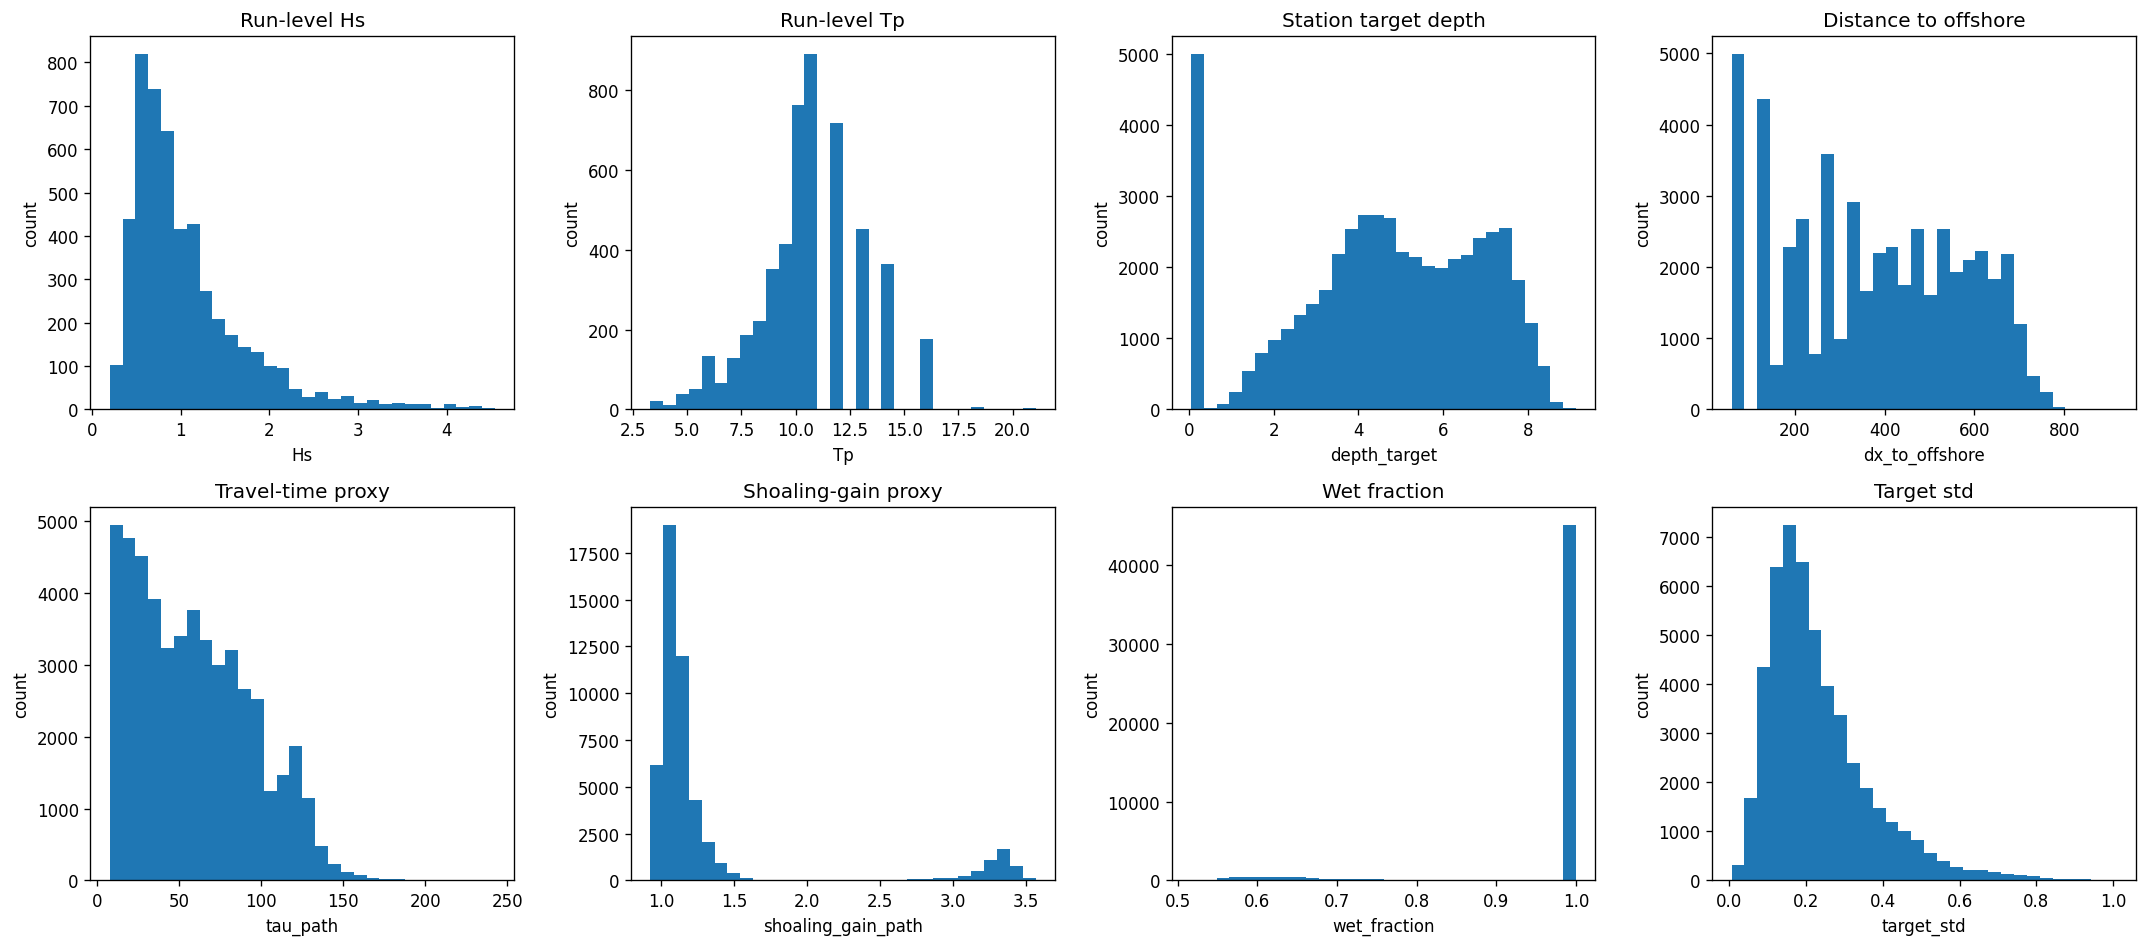

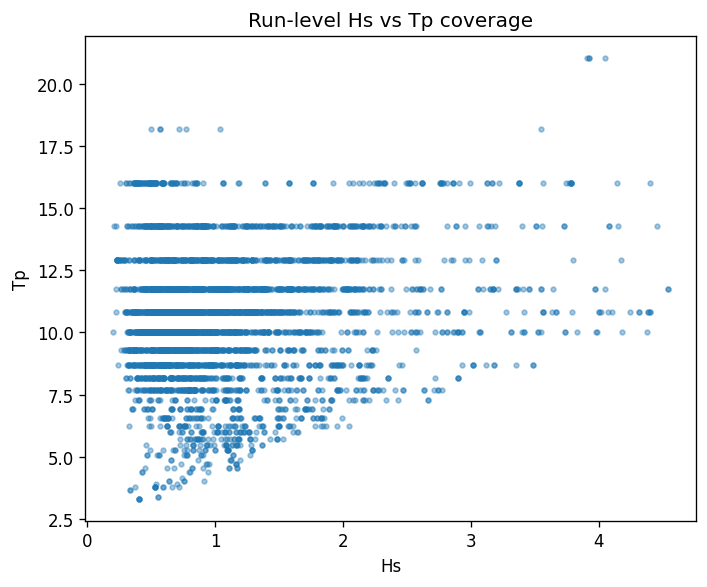

In [8]:
# =========================
# Coverage EDA plots
# =========================
if isinstance(selected_meta_df, pd.DataFrame) and isinstance(sample_manifest_df, pd.DataFrame):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    plot_cols = [
        ("Hs", selected_meta_df, "Run-level Hs"),
        ("Tp", selected_meta_df, "Run-level Tp"),
        ("depth_target", sample_manifest_df, "Station target depth"),
        ("dx_to_offshore", sample_manifest_df, "Distance to offshore"),
        ("tau_path", sample_manifest_df, "Travel-time proxy"),
        ("shoaling_gain_path", sample_manifest_df, "Shoaling-gain proxy"),
        ("wet_fraction", sample_manifest_df, "Wet fraction"),
        ("target_std", sample_manifest_df, "Target std"),
    ]

    for ax, (col, df, title) in zip(axes.ravel(), plot_cols):
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        ax.hist(vals, bins=30)
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel("count")

    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_ROOT / "eda_feature_distributions.png", bbox_inches="tight", dpi=160)
    plt.show()

    if {"Hs", "Tp"}.issubset(selected_meta_df.columns):
        plt.figure(figsize=(6, 5))
        scatter_df = selected_meta_df[["Hs", "Tp"]].dropna().copy()
        if len(scatter_df) > 5000:
            scatter_df = scatter_df.sample(5000, random_state=42)
        plt.scatter(scatter_df["Hs"], scatter_df["Tp"], s=8, alpha=0.4)
        plt.xlabel("Hs")
        plt.ylabel("Tp")
        plt.title("Run-level Hs vs Tp coverage")
        plt.tight_layout()
        plt.savefig(OUTPUT_FIG_ROOT / "eda_hs_vs_tp_scatter.png", bbox_inches="tight", dpi=160)
        plt.show()
else:
    print("Full saved metadata/sample-manifest CSVs are not available in this session.")
    print("The notebook can still use the recovered example stationization figure below.")


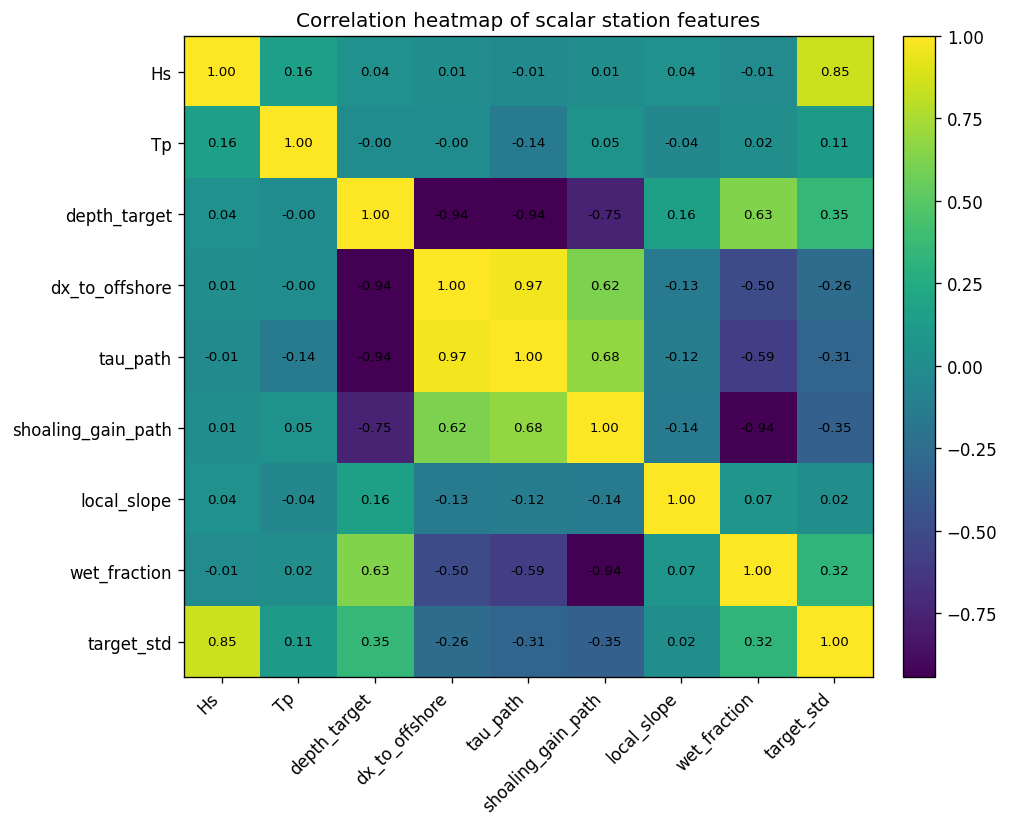

,feature_1,feature_2,corr
4,dx_to_offshore,tau_path,0.966914
5,shoaling_gain_path,wet_fraction,-0.944402
2,depth_target,tau_path,-0.944294
1,depth_target,dx_to_offshore,-0.938414
0,Hs,target_std,0.852047
3,depth_target,shoaling_gain_path,-0.752371


In [9]:
# =========================
# Feature correlation analysis
# =========================
corr_features = [
    "Hs", "Tp", "depth_target", "dx_to_offshore",
    "tau_path", "shoaling_gain_path", "local_slope",
    "wet_fraction", "target_std"
]

if isinstance(sample_manifest_df, pd.DataFrame) and all(col in sample_manifest_df.columns for col in corr_features):
    corr_df = sample_manifest_df[corr_features].apply(pd.to_numeric, errors="coerce")
    corr_matrix = corr_df.corr(numeric_only=True)
    corr_matrix.to_csv(OUTPUT_TABLE_ROOT / "scalar_feature_correlation_matrix.csv")

    fig, ax = plt.subplots(figsize=(8.5, 7))
    im = ax.imshow(corr_matrix.values, aspect="auto")
    ax.set_xticks(range(len(corr_features)))
    ax.set_xticklabels(corr_features, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_features)))
    ax.set_yticklabels(corr_features)

    for i in range(len(corr_features)):
        for j in range(len(corr_features)):
            val = corr_matrix.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("Correlation heatmap of scalar station features")
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_ROOT / "scalar_feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
    plt.show()

    high_corr_pairs = []
    for i, c1 in enumerate(corr_features):
        for j, c2 in enumerate(corr_features):
            if j <= i:
                continue
            val = corr_matrix.loc[c1, c2]
            if np.isfinite(val) and abs(val) >= 0.70:
                high_corr_pairs.append({"feature_1": c1, "feature_2": c2, "corr": float(val)})

    high_corr_pairs_df = (
        pd.DataFrame(high_corr_pairs).sort_values("corr", key=np.abs, ascending=False)
        if high_corr_pairs else
        pd.DataFrame(columns=["feature_1", "feature_2", "corr"])
    )
    display(high_corr_pairs_df)
    high_corr_pairs_df.to_csv(OUTPUT_TABLE_ROOT / "high_correlation_feature_pairs.csv", index=False)
else:
    print("Correlation heatmap skipped because the full station sample manifest is not available in this session.")


,split_a,split_b,run_overlap_count,profile_overlap_count,run_station_overlap_count
0,test,train,0,0,0
1,test,val,0,0,0
2,train,val,0,0,0


Hs                                                 Tp            \
           mean       std    median       min       max       mean       std   
split                                                                          
test   1.072784  0.691834  0.850708  0.227440  4.396853  10.466668  2.364659   
train  1.064487  0.659478  0.867930  0.200222  4.542076  10.526855  2.414966   
val    1.061005  0.637824  0.856417  0.293536  4.017609  10.644669  2.438047   

                                       ... wet_fraction                   \
          median       min        max  ...         mean       std median   
split                                  ...                                 
test   10.810811  3.773585  16.000000  ...     0.966016  0.105838    1.0   
train  10.810811  3.305785  21.052631  ...     0.965950  0.106849    1.0   
val    10.810811  3.305785  18.181818  ...     0.966624  0.105380    1.0   

                     target_std                                          
            min  max       mean       std    median       min       max  
split                                                                    
test   0.530926  1.0   0.233825  0.138858  0.196624  0.015186  1.009110  
train  0.516628  1.0   0.233289  0.135217  0.200225  0.006779  0.996633  
val    0.521571  1.0   0.232994  0.132684  0.197717  0.010610  0.941677  

[3 rows x 35 columns]

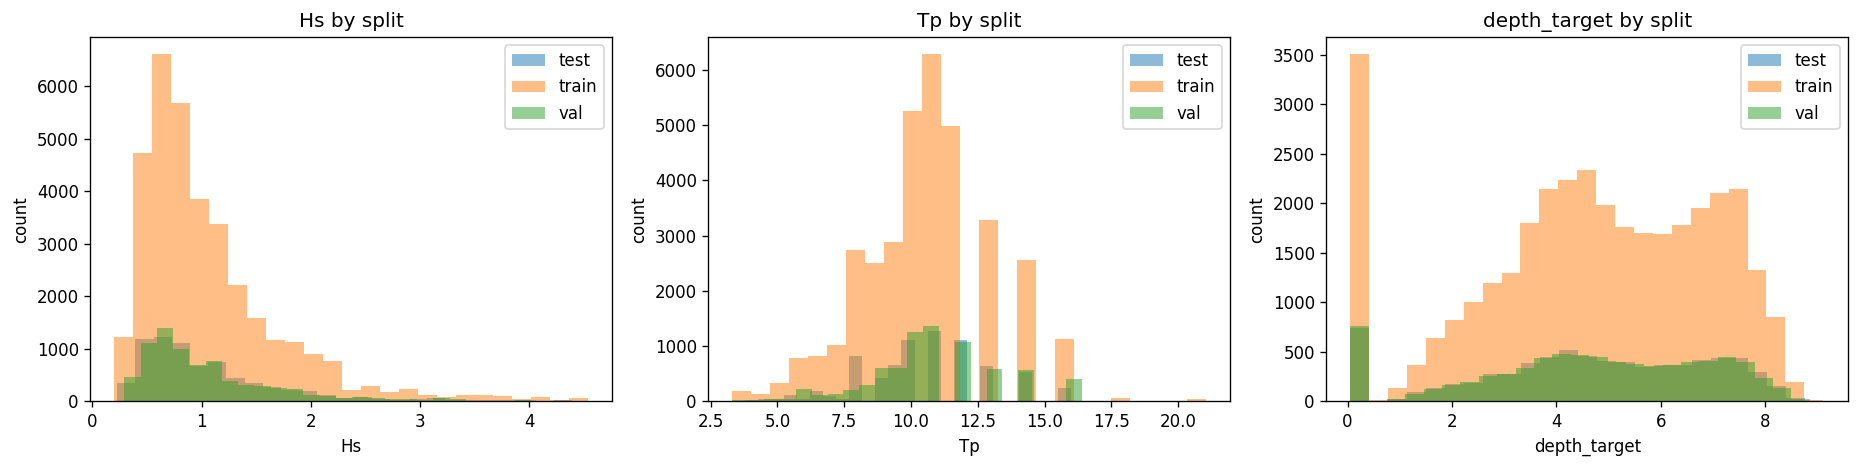

In [10]:
# =========================
# Split integrity and distribution shift
# =========================
if isinstance(sample_manifest_with_splits_df, pd.DataFrame) and "split" in sample_manifest_with_splits_df.columns:
    split_df = sample_manifest_with_splits_df.copy()

    split_sets = {}
    for split_name in sorted(split_df["split"].dropna().unique()):
        sub = split_df[split_df["split"] == split_name].copy()
        run_ids = set(sub["run_id"].astype(str)) if "run_id" in sub.columns else set()
        profile_hashes = set(sub["profile_hash"].astype(str)) if "profile_hash" in sub.columns else set()
        run_station_keys = set((sub["run_id"].astype(str) + "||" + sub["station_id"].astype(str)).tolist()) if {"run_id", "station_id"}.issubset(sub.columns) else set()
        split_sets[split_name] = {
            "run_ids": run_ids,
            "profile_hashes": profile_hashes,
            "run_station_keys": run_station_keys,
        }

    integrity_rows = []
    split_names = list(split_sets.keys())
    for i in range(len(split_names)):
        for j in range(i + 1, len(split_names)):
            a, b = split_names[i], split_names[j]
            integrity_rows.append({
                "split_a": a,
                "split_b": b,
                "run_overlap_count": len(split_sets[a]["run_ids"] & split_sets[b]["run_ids"]),
                "profile_overlap_count": len(split_sets[a]["profile_hashes"] & split_sets[b]["profile_hashes"]),
                "run_station_overlap_count": len(split_sets[a]["run_station_keys"] & split_sets[b]["run_station_keys"]),
            })

    split_integrity_df = pd.DataFrame(integrity_rows)
    display(split_integrity_df)
    split_integrity_df.to_csv(OUTPUT_TABLE_ROOT / "split_integrity_checks.csv", index=False)

    summary_cols = [c for c in ["Hs", "Tp", "depth_target", "dx_to_offshore", "tau_path", "wet_fraction", "target_std"] if c in split_df.columns]
    split_distribution_df = split_df.groupby("split")[summary_cols].agg(["mean", "std", "median", "min", "max"])
    display(split_distribution_df)
    split_distribution_df.to_csv(OUTPUT_TABLE_ROOT / "split_distribution_summary.csv")

    plot_cols = [c for c in ["Hs", "Tp", "depth_target"] if c in split_df.columns]
    if len(plot_cols):
        fig, axes = plt.subplots(1, len(plot_cols), figsize=(5.2 * len(plot_cols), 4))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            for split_name, sub in split_df.groupby("split"):
                ax.hist(pd.to_numeric(sub[col], errors="coerce").dropna(), bins=25, alpha=0.5, label=split_name)
            ax.set_title(f"{col} by split")
            ax.set_xlabel(col)
            ax.set_ylabel("count")
            ax.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_FIG_ROOT / "split_distribution_comparison.png", dpi=160, bbox_inches="tight")
        plt.show()
else:
    print("Full split-aware manifest not available. Using split counts recovered from the saved notebook output.")
    split_count_df = pd.DataFrame([
        ["train", recovered_counts.get("train_samples", np.nan), recovered_counts.get("train_unique_runs", np.nan)],
        ["val", recovered_counts.get("val_samples", np.nan), recovered_counts.get("val_unique_runs", np.nan)],
        ["test", recovered_counts.get("test_samples", np.nan), recovered_counts.get("test_unique_runs", np.nan)],
    ], columns=["split", "station_samples", "unique_runs"])
    display(split_count_df)
    split_count_df.to_csv(OUTPUT_TABLE_ROOT / "split_counts_recovered_from_notebook.csv", index=False)

    split_depth_describe_df = tables.get("split_depth_describe_df")
    if isinstance(split_depth_describe_df, pd.DataFrame):
        display(split_depth_describe_df)
        split_depth_describe_df.to_csv(OUTPUT_TABLE_ROOT / "split_depth_describe_recovered.csv", index=False)


## Methodology and Training Summary

These cells turn the saved configuration and training logs into report-ready methodology assets:
- model design summary
- split / training configuration summary
- training-curve summary
- best-epoch table


In [11]:
# =========================
# Model and training configuration summary
# =========================
param_counts = {}
if USE_MODEL_BUNDLES_FOR_PARAM_COUNTS and ARTIFACT_ROOT is not None and (ARTIFACT_ROOT / "models").exists():
    param_counts = count_saved_model_parameters(ARTIFACT_ROOT / "models")

model_summary_rows = []

stage1_alpha_grid = cfg_recovered.get("stage1_alpha_grid", [])
stage1_best_alpha = recovered_counts.get("stage1_best_alpha", np.nan)
stage1_val_mse = recovered_counts.get("stage1_val_mse", np.nan)

model_summary_rows.append({
    "model": "stage1_ridge",
    "type": "multi-output ridge regression on forcing-period coefficients",
    "feature_schema": cfg_recovered.get("stage1_feature_schema", "strict_core"),
    "channel_schema": "forcing-period coefficient basis",
    "hidden_or_width": "linear model",
    "kernel_or_basis": "period basis",
    "dilations": np.nan,
    "batch_size": np.nan,
    "epochs": np.nan,
    "patience": np.nan,
    "learning_rate": np.nan,
    "weight_decay": np.nan,
    "trainable_parameters": param_counts.get("stage1_ridge", np.nan),
    "selection_detail": f"alpha grid={stage1_alpha_grid} | best alpha={stage1_best_alpha} | val MSE={stage1_val_mse}",
})

model_summary_rows.append({
    "model": "stage2_tcn",
    "type": "full-sequence conditional temporal convolutional network",
    "feature_schema": cfg_recovered.get("stage2_feature_schema", "with_geometry"),
    "channel_schema": cfg_recovered.get("stage2_channel_schema", "core_derived"),
    "hidden_or_width": cfg_recovered.get("stage2_hidden_channels", np.nan),
    "kernel_or_basis": cfg_recovered.get("stage2_kernel_size", np.nan),
    "dilations": cfg_recovered.get("stage2_dilations", np.nan),
    "batch_size": cfg_recovered.get("stage2_batch_size", np.nan),
    "epochs": cfg_recovered.get("stage2_epochs", np.nan),
    "patience": cfg_recovered.get("stage2_patience", np.nan),
    "learning_rate": cfg_recovered.get("stage2_learning_rate", np.nan),
    "weight_decay": cfg_recovered.get("stage2_weight_decay", np.nan),
    "trainable_parameters": param_counts.get("stage2_tcn", np.nan),
    "selection_detail": "best validation checkpoint retained",
})

model_summary_rows.append({
    "model": "stage3_hybrid",
    "type": "physics-informed residual TCN with differentiable delay-and-gain baseline",
    "feature_schema": cfg_recovered.get("stage3_feature_schema", "with_physics_aux"),
    "channel_schema": cfg_recovered.get("stage3_channel_schema", "physics_augmented"),
    "hidden_or_width": cfg_recovered.get("stage3_hidden_channels", np.nan),
    "kernel_or_basis": cfg_recovered.get("stage3_kernel_size", np.nan),
    "dilations": cfg_recovered.get("stage3_dilations", np.nan),
    "batch_size": cfg_recovered.get("stage3_batch_size", np.nan),
    "epochs": cfg_recovered.get("stage3_epochs", np.nan),
    "patience": cfg_recovered.get("stage3_patience", np.nan),
    "learning_rate": cfg_recovered.get("stage3_learning_rate", np.nan),
    "weight_decay": cfg_recovered.get("stage3_weight_decay", np.nan),
    "trainable_parameters": param_counts.get("stage3_hybrid", np.nan),
    "selection_detail": (
        f"corr_w={cfg_recovered.get('corr_loss_weight', np.nan)}, "
        f"IG_w={cfg_recovered.get('ig_loss_weight', np.nan)}, "
        f"SS_w={cfg_recovered.get('ss_loss_weight', np.nan)}, "
        f"phys_reg_w={cfg_recovered.get('physics_reg_weight', np.nan)}"
    ),
})

model_summary_df = pd.DataFrame(model_summary_rows)
display(model_summary_df)
model_summary_df.to_csv(OUTPUT_TABLE_ROOT / "model_training_configuration_summary.csv", index=False)
save_df_as_png(model_summary_df, OUTPUT_FIG_ROOT / "model_training_configuration_table.png", title="Model and training configuration", max_rows=10, font_size=7)


Could not load stage2_fullseq_tcn_bundle.pt: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the

,model,type,feature_schema,channel_schema,hidden_or_width,kernel_or_basis,dilations,batch_size,epochs,patience,learning_rate,weight_decay,trainable_parameters,selection_detail
0,stage1_ridge,multi-output ridge regression on forcing-perio...,strict_core,forcing-period coefficient basis,linear model,period basis,NaN,NaN,NaN,NaN,NaN,NaN,15872.0,"alpha grid=[0.0001, 0.001, 0.01, 0.1, 1.0, 10...."
1,stage2_tcn,full-sequence conditional temporal convolution...,with_geometry,core_derived,32,5,"[1, 2, 4, 8, 16, 32, 64, 128]",2.0,20.0,5.0,0.0008,0.0001,NaN,best validation checkpoint retained
2,stage3_hybrid,physics-informed residual TCN with differentia...,with_physics_aux,physics_augmented,32,5,"[1, 2, 4, 8, 16, 32, 64, 128]",2.0,25.0,6.0,0.0007,0.0001,NaN,"corr_w=0.12, IG_w=0.06, SS_w=0.08, phys_reg_w=..."


WindowsPath('funwave_capstone_report_support_outputs/figures/model_training_configuration_table.png')

,model,epochs_ran,configured_epochs,best_epoch,best_val_total,train_total_at_best,generalization_gap_at_best
0,stage2_tcn,20,20,15,0.2362,0.2532,-0.0170
1,stage3_hybrid,25,25,23,0.1137,0.1212,-0.0075


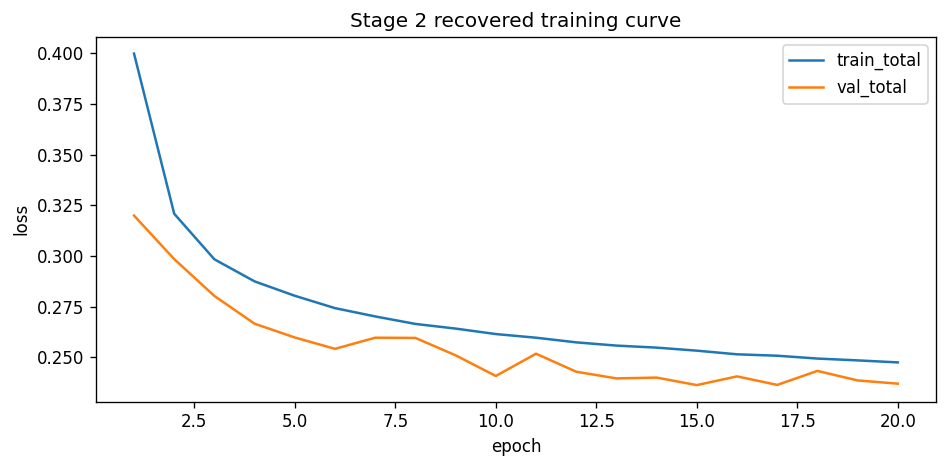

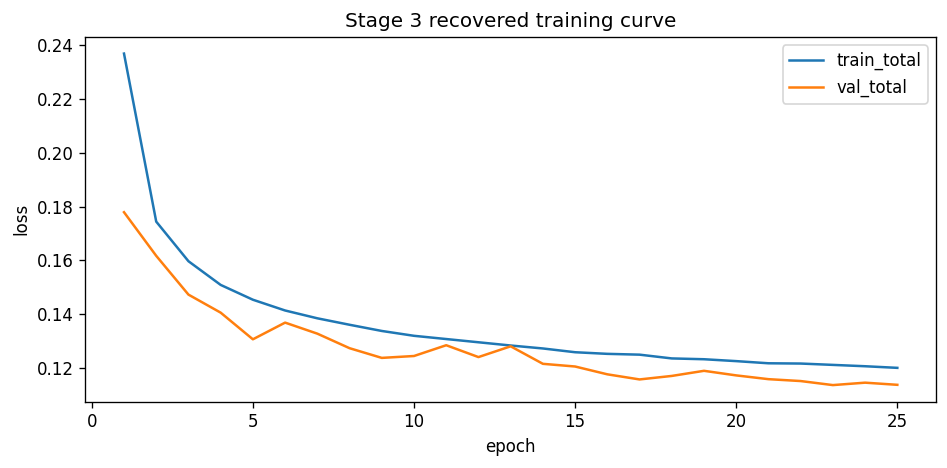

In [12]:
# =========================
# Training history summary
# =========================
stage2_history_df.to_csv(OUTPUT_TABLE_ROOT / "stage2_training_history_recovered.csv", index=False)
stage3_history_df.to_csv(OUTPUT_TABLE_ROOT / "stage3_training_history_recovered.csv", index=False)

history_summary_rows = []
for model_name, hist_df in [("stage2_tcn", stage2_history_df), ("stage3_hybrid", stage3_history_df)]:
    if hist_df is None or len(hist_df) == 0:
        continue
    best_idx = hist_df["val_total"].idxmin()
    best_row = hist_df.loc[best_idx]
    history_summary_rows.append({
        "model": model_name,
        "epochs_ran": int(hist_df["epoch"].max()),
        "configured_epochs": int(cfg_recovered.get("stage2_epochs", np.nan)) if model_name == "stage2_tcn" else int(cfg_recovered.get("stage3_epochs", np.nan)),
        "best_epoch": int(best_row["epoch"]),
        "best_val_total": float(best_row["val_total"]),
        "train_total_at_best": float(best_row["train_total"]),
        "generalization_gap_at_best": float(best_row["val_total"] - best_row["train_total"]),
    })

history_summary_df = pd.DataFrame(history_summary_rows)
display(history_summary_df)
history_summary_df.to_csv(OUTPUT_TABLE_ROOT / "training_history_summary.csv", index=False)
save_df_as_png(history_summary_df.round(4), OUTPUT_FIG_ROOT / "training_history_summary_table.png", title="Recovered training summary")

if len(stage2_history_df):
    plt.figure(figsize=(8, 4))
    plt.plot(stage2_history_df["epoch"], stage2_history_df["train_total"], label="train_total")
    plt.plot(stage2_history_df["epoch"], stage2_history_df["val_total"], label="val_total")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Stage 2 recovered training curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_ROOT / "stage2_training_curve_recovered.png", dpi=160, bbox_inches="tight")
    plt.show()

if len(stage3_history_df):
    plt.figure(figsize=(8, 4))
    plt.plot(stage3_history_df["epoch"], stage3_history_df["train_total"], label="train_total")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_total"], label="val_total")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Stage 3 recovered training curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_ROOT / "stage3_training_curve_recovered.png", dpi=160, bbox_inches="tight")
    plt.show()


## Results and Analysis

These cells generate the core **Results** section assets:
- main held-out model comparison table
- compact metric figure
- depth-wise performance analysis
- per-sample error analysis (when the saved per-sample CSV is available)
- recovered representative prediction figures


,model,rmse,mae,r2,corr,lag_abs_seconds,band_rel_err_0,band_rel_err_1,improvement_vs_physics_rmse_pct,improvement_vs_physics_mae_pct,...,improvement_vs_physics_band_rel_err_1_pct,delta_vs_physics_corr,delta_vs_physics_r2,improvement_vs_stage2_rmse_pct,improvement_vs_stage2_mae_pct,improvement_vs_stage2_lag_abs_seconds_pct,improvement_vs_stage2_band_rel_err_0_pct,improvement_vs_stage2_band_rel_err_1_pct,delta_vs_stage2_corr,delta_vs_stage2_r2
0,physics_baseline,0.4229,0.3348,-27.8154,0.0282,4.8444,3.0293,81.9894,0.0000,0.0000,...,0.0000,0.0000,0.0000,-203.1118,-213.0862,-391.8150,-731.9072,-19036.1629,-0.6557,-26.4167
1,stage1_ridge,0.2555,0.2064,-8.6188,0.1365,20.3152,0.9933,1.1044,39.5809,38.3427,...,98.6530,0.1083,19.1966,-83.1375,-93.0405,-1962.4464,-172.7720,-157.7667,-0.5474,-7.2201
2,stage2_tcn,0.1395,0.1069,-1.3987,0.6839,0.9850,0.3641,0.4285,67.0089,68.0599,...,99.4774,0.6557,26.4167,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,stage3_hybrid,0.0862,0.0651,-1.9685,0.8906,0.2305,0.2374,0.1794,79.6116,80.5684,...,99.7812,0.8624,25.8469,38.2002,39.1625,76.5991,34.8139,58.1355,0.2067,-0.5698


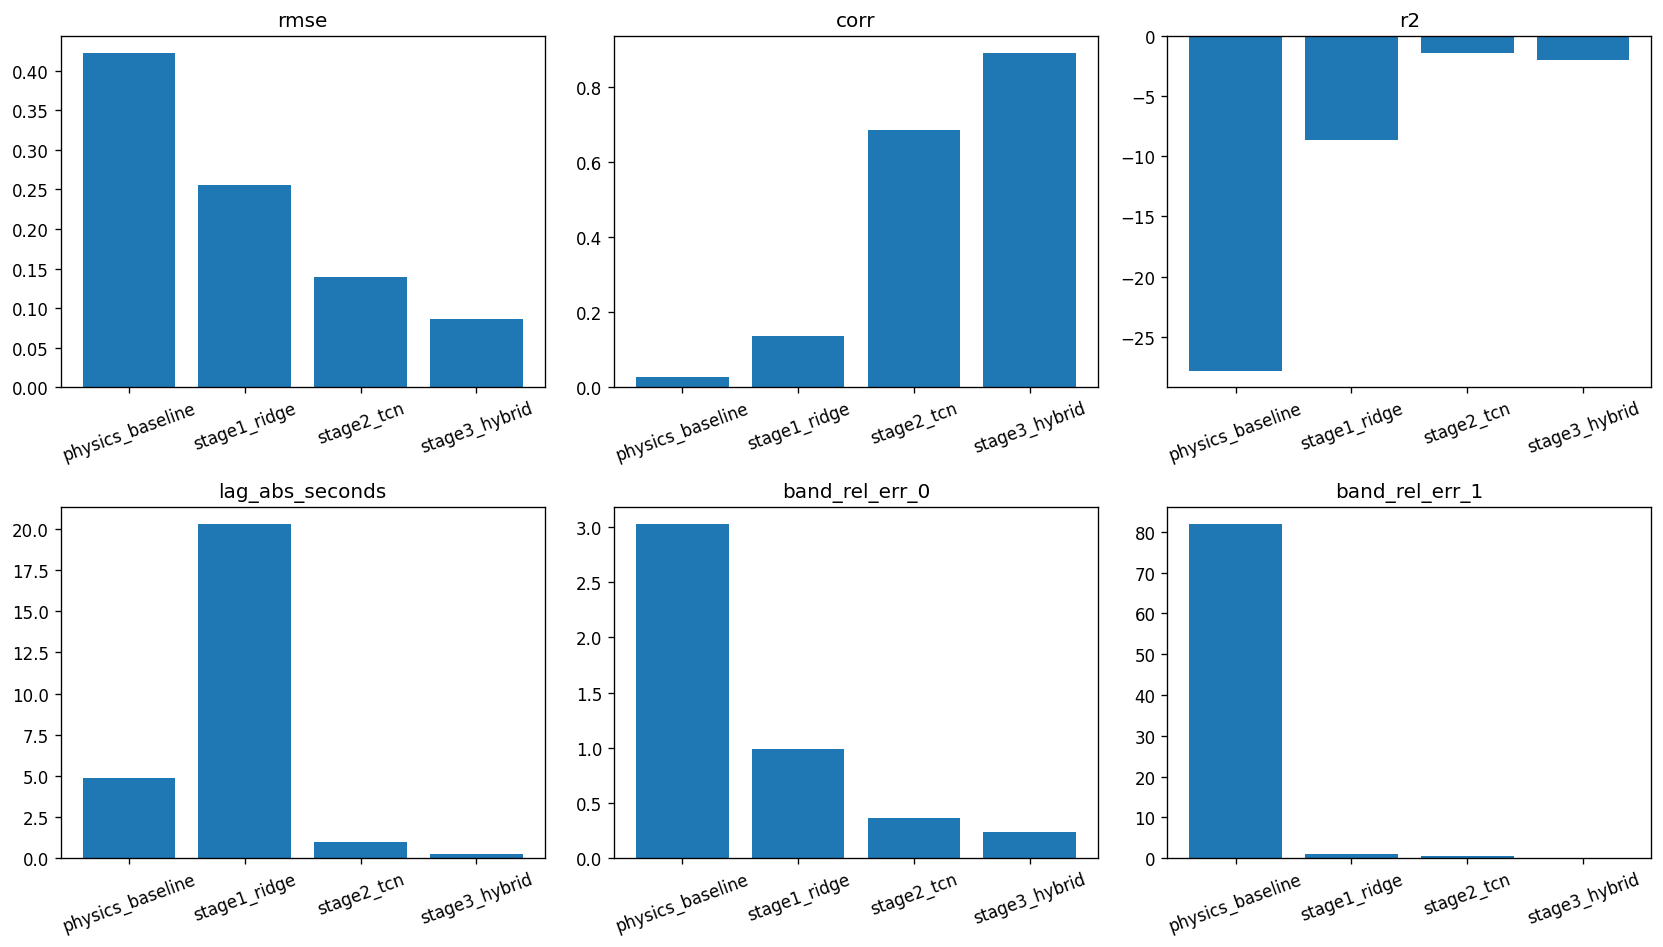

,metric,best_model,value
0,rmse,stage3_hybrid,0.086218
1,mae,stage3_hybrid,0.065056
2,r2,stage2_tcn,-1.398722
3,corr,stage3_hybrid,0.890606
4,lag_abs_seconds,stage3_hybrid,0.230501
5,band_rel_err_0,stage3_hybrid,0.237368
6,band_rel_err_1,stage3_hybrid,0.179369


In [13]:
# =========================
# Main held-out comparison table
# =========================
summary_df = tables.get("summary_df")
if not isinstance(summary_df, pd.DataFrame):
    raise RuntimeError("Could not recover the held-out model comparison summary from saved data.")

summary_df = clean_dataframe(summary_df).copy()
for col in summary_df.columns:
    if col != "model":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

metric_cols = ["rmse", "mae", "r2", "corr", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"]
direction = {
    "rmse": "lower",
    "mae": "lower",
    "r2": "higher",
    "corr": "higher",
    "lag_abs_seconds": "lower",
    "band_rel_err_0": "lower",
    "band_rel_err_1": "lower",
}

results_table_df = summary_df.copy()

physics_row = results_table_df.loc[results_table_df["model"] == "physics_baseline"]
stage2_row = results_table_df.loc[results_table_df["model"] == "stage2_tcn"]

if len(physics_row):
    physics_row = physics_row.iloc[0]
    for m in ["rmse", "mae", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"]:
        results_table_df[f"improvement_vs_physics_{m}_pct"] = (
            100.0 * (physics_row[m] - results_table_df[m]) / max(abs(float(physics_row[m])), 1e-12)
        )
    for m in ["corr", "r2"]:
        results_table_df[f"delta_vs_physics_{m}"] = results_table_df[m] - float(physics_row[m])

if len(stage2_row):
    stage2_row = stage2_row.iloc[0]
    for m in ["rmse", "mae", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"]:
        results_table_df[f"improvement_vs_stage2_{m}_pct"] = (
            100.0 * (stage2_row[m] - results_table_df[m]) / max(abs(float(stage2_row[m])), 1e-12)
        )
    for m in ["corr", "r2"]:
        results_table_df[f"delta_vs_stage2_{m}"] = results_table_df[m] - float(stage2_row[m])

display(results_table_df.round(4))
results_table_df.to_csv(OUTPUT_TABLE_ROOT / "heldout_model_comparison_detailed.csv", index=False)
save_df_as_png(
    results_table_df[["model"] + metric_cols].round(4),
    OUTPUT_FIG_ROOT / "heldout_model_comparison_table.png",
    title="Held-out model comparison",
    max_rows=10,
    font_size=8
)

plot_metrics = ["rmse", "corr", "r2", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, metric in zip(axes.ravel(), plot_metrics):
    ax.bar(results_table_df["model"], results_table_df[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_FIG_ROOT / "heldout_model_comparison_compact.png", dpi=160, bbox_inches="tight")
plt.show()

best_metric_rows = []
for m in metric_cols:
    ascending = direction[m] == "lower"
    best_row = summary_df.sort_values(m, ascending=ascending).iloc[0]
    best_metric_rows.append({"metric": m, "best_model": best_row["model"], "value": best_row[m]})
best_metric_df = pd.DataFrame(best_metric_rows)
display(best_metric_df)
best_metric_df.to_csv(OUTPUT_TABLE_ROOT / "best_model_by_metric.csv", index=False)



=== Hs_bin ===


,model,Hs_bin,rmse,mae,r2,corr,lag_abs_seconds,band_rel_err_0,band_rel_err_1
0,physics_baseline,<=0.75,0.262160,0.209313,-11.116707,0.017007,3.984324,1.938875,12.811286
1,physics_baseline,0.75-1.5,0.411820,0.327627,-31.230114,0.031046,4.721902,3.420773,121.103116
2,physics_baseline,1.5-2.5,0.688682,0.540148,-61.088546,0.040027,6.714393,4.734875,159.418769
3,physics_baseline,>2.5,1.148770,0.894721,-38.819338,0.066072,7.807742,3.702370,90.445142
4,stage1_ridge,<=0.75,0.164167,0.133474,-2.727089,0.145374,20.992297,0.993862,0.971432
5,stage1_ridge,0.75-1.5,0.253864,0.206207,-11.207775,0.140783,20.283541,0.992119,1.221521
6,stage1_ridge,1.5-2.5,0.406607,0.325357,-18.855609,0.117649,19.127103,0.994032,1.150058
7,stage1_ridge,>2.5,0.622064,0.494674,-4.069878,0.074642,18.263226,0.996247,1.064330
8,stage2_tcn,<=0.75,0.093327,0.073344,0.100455,0.667091,1.025068,0.347005,0.414566
9,stage2_tcn,0.75-1.5,0.136702,0.105776,-2.360984,0.689906,1.035148,0.370586,0.442060



=== Tp_bin ===


,model,Tp_bin,rmse,mae,r2,corr,lag_abs_seconds,band_rel_err_0,band_rel_err_1
0,physics_baseline,<=6,0.368979,0.295567,-142.203377,0.005543,7.776000,3.805116,286.453690
1,physics_baseline,6-8,0.430864,0.344518,-45.376810,-0.020832,4.528000,4.472047,128.010505
2,physics_baseline,8-10,0.383596,0.305290,-24.248709,-0.054325,4.516466,2.694655,47.522780
3,physics_baseline,>10,0.452894,0.356514,-19.161132,0.098415,4.945416,2.925840,83.611284
4,stage1_ridge,<=6,0.243194,0.201583,-73.954179,0.097625,20.851200,0.989780,1.463916
5,stage1_ridge,6-8,0.263796,0.217510,-19.034354,0.125872,21.068800,0.989238,1.234788
6,stage1_ridge,8-10,0.228916,0.186486,-7.201162,0.161941,20.723684,0.991471,1.043261
7,stage1_ridge,>10,0.273610,0.218743,-3.156478,0.123095,19.836515,0.995593,1.097704
8,stage2_tcn,<=6,0.152575,0.121822,-17.868410,0.586320,1.540800,0.651373,0.695603
9,stage2_tcn,6-8,0.152928,0.119481,-5.811667,0.615436,1.248000,0.426716,0.490338



=== wet_bin ===


,model,wet_bin,rmse,mae,r2,corr,lag_abs_seconds,band_rel_err_0,band_rel_err_1
0,physics_baseline,<=0.70,0.940226,0.768885,-222.308495,0.024678,9.761578,28.833920,700.973889
1,physics_baseline,0.70-0.85,0.701261,0.575742,-448.044318,0.054972,7.504839,18.131024,1101.577072
2,physics_baseline,0.85-0.95,0.861303,0.699559,-352.551310,-0.067286,14.500000,12.628699,2446.511861
3,physics_baseline,>0.95,0.371259,0.291359,-2.107542,0.028260,4.338725,0.465227,2.490839
4,stage1_ridge,<=0.70,0.349873,0.330111,-70.519518,-0.003265,16.490223,0.926320,1.944274
5,stage1_ridge,0.70-0.85,0.259190,0.235303,-168.703950,0.005191,18.101613,0.976544,3.285364
6,stage1_ridge,0.85-0.95,0.339949,0.322494,-60.605209,-0.008398,17.600000,0.973815,6.812978
7,stage1_ridge,>0.95,0.246946,0.194757,-0.085522,0.151557,20.698335,0.999487,0.974951
8,stage2_tcn,<=0.70,0.128105,0.109817,-16.632121,0.396732,2.549228,0.973138,0.949250
9,stage2_tcn,0.70-0.85,0.124924,0.106134,-34.393659,0.366098,2.883871,1.650407,1.185605


,quantile,rmse,mae,r2,corr,lag_abs_seconds
0,0.50,0.0629,0.0489,0.8992,0.9504,0.0
1,0.90,0.1724,0.1254,0.9742,0.9880,0.6
2,0.95,0.2361,0.1727,0.9810,0.9911,0.6


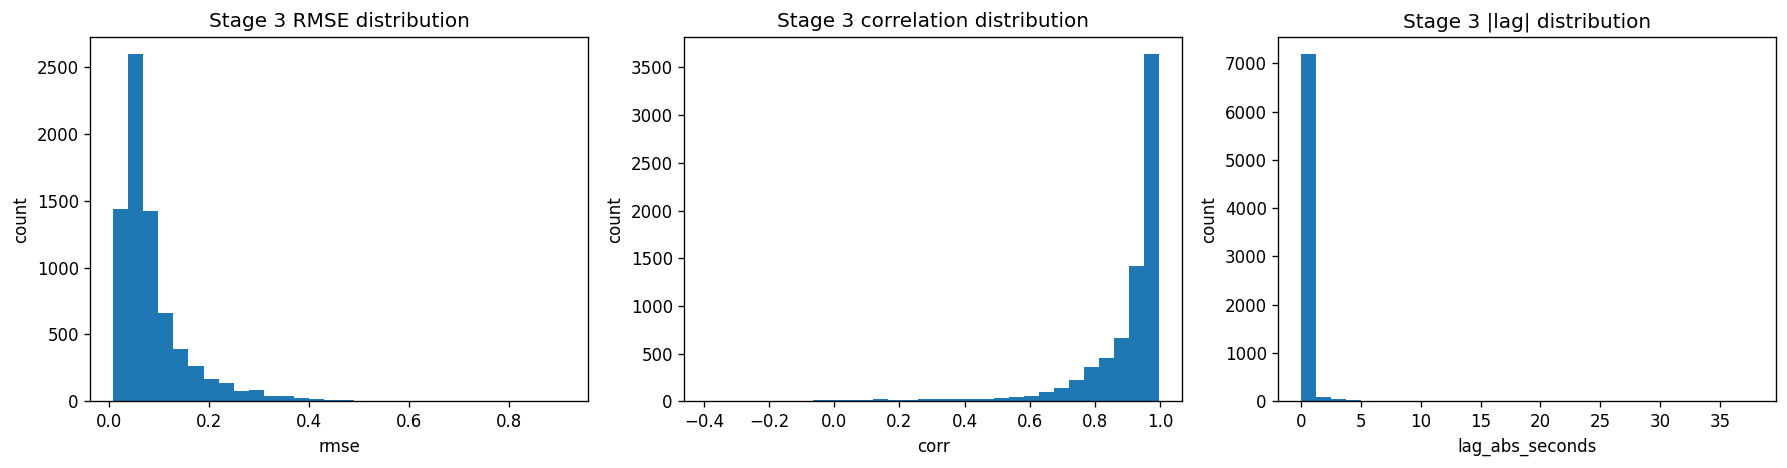

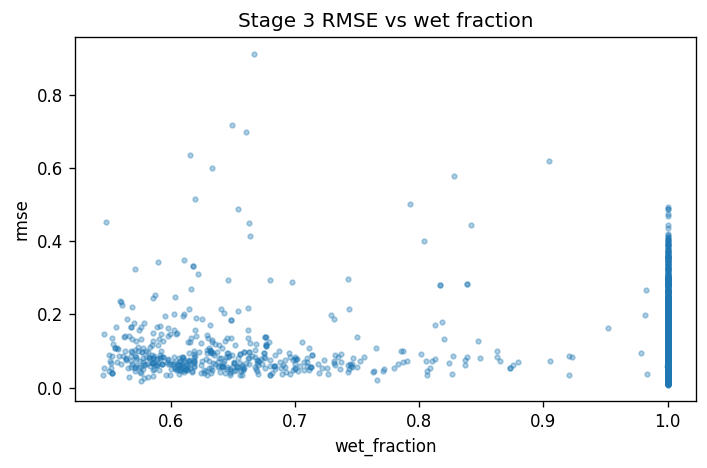

,run_id,station_id,Hs,Tp,wet_fraction,target_std,rmse,corr,lag_abs_seconds
27260,input_01170,station_00,0.298226,8.163265,1.0,0.072897,0.007435,0.994994,0.0
23820,input_03646,station_00,0.346458,6.896552,1.0,0.085936,0.008241,0.995865,0.0
26140,input_04217,station_00,0.728287,12.903226,1.0,0.185638,0.009403,0.997504,0.0
26141,input_04217,station_01,0.728287,12.903226,1.0,0.186279,0.009562,0.997401,0.0
26142,input_04217,station_02,0.728287,12.903226,1.0,0.187749,0.010248,0.997142,0.0
24780,input_03047,station_00,0.334911,9.302325,1.0,0.083185,0.010691,0.991985,0.0
26143,input_04217,station_03,0.728287,12.903226,1.0,0.191062,0.010844,0.997034,0.0
23821,input_03646,station_01,0.346458,6.896552,1.0,0.085728,0.010886,0.993296,0.0
26130,input_04055,station_00,0.327902,9.302325,1.0,0.082818,0.010948,0.991429,0.0
23050,input_04055,station_00,0.327902,9.302325,1.0,0.082818,0.010948,0.991429,0.0


,run_id,station_id,Hs,Tp,wet_fraction,target_std,rmse,corr,lag_abs_seconds
24539,input_01877,station_09,1.171471,6.557377,0.667505,0.021352,0.913608,-0.190304,5.4
28879,input_03884,station_09,1.710644,10.000000,0.710928,0.022037,0.844163,0.005564,10.2
24379,input_01352,station_09,2.717297,8.163265,0.649180,0.093815,0.718127,0.506742,3.0
23779,input_03386,station_09,1.944852,14.285714,0.660977,0.052364,0.697744,0.295182,4.8
29519,input_08708,station_09,1.142465,5.714286,0.615879,0.015186,0.635531,-0.179500,31.2
22269,input_00532,station_09,1.778493,14.285714,0.904762,0.060818,0.619706,0.520379,6.6
27259,input_00405,station_09,0.513679,8.163265,0.612190,0.065868,0.619687,0.235620,1.8
24959,input_03813,station_09,0.539753,11.764706,0.633075,0.084969,0.600814,0.377345,1.2
22289,input_00708,station_09,3.526132,10.000000,0.692490,0.232485,0.589402,0.250473,7.8
29299,input_00350,station_09,1.473185,7.692308,0.828099,0.077933,0.578041,0.059280,12.6


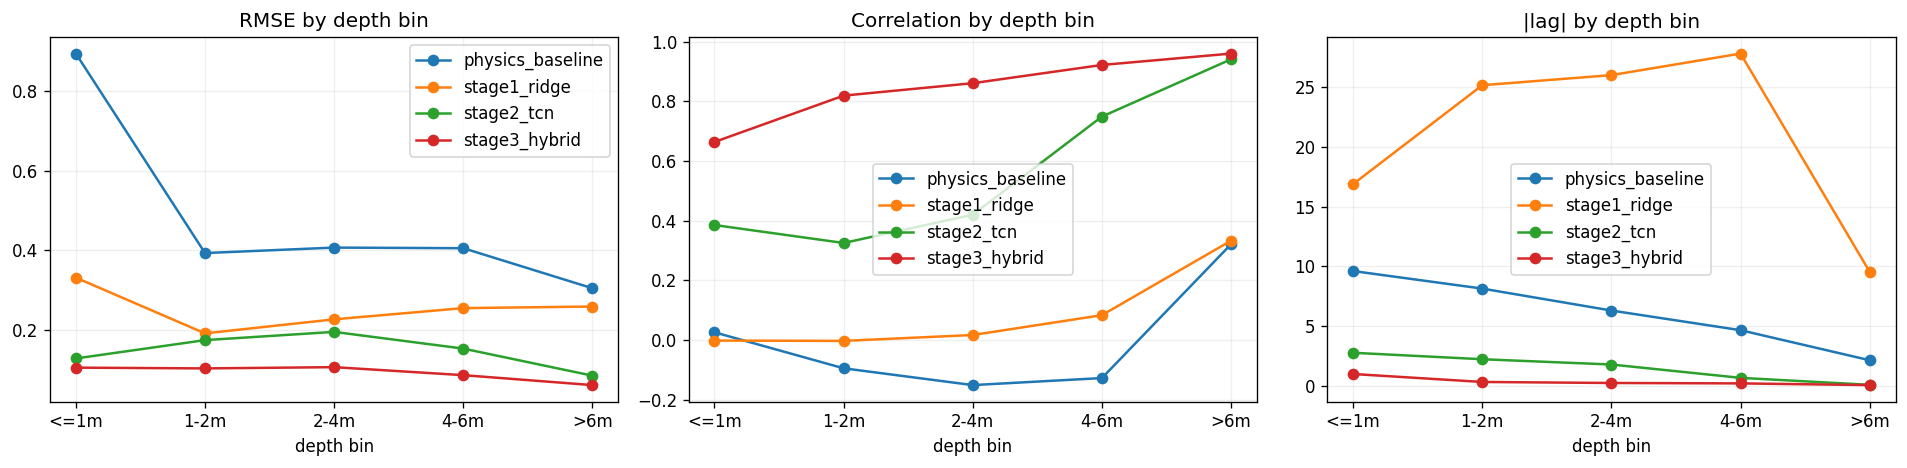

In [14]:
# =========================
# Depth-wise and regime-wise analysis
# =========================
comparison_df = tables.get("comparison_df")
depth_summary_df = tables.get("depth_summary_df")

if isinstance(comparison_df, pd.DataFrame):
    comparison_df = clean_dataframe(comparison_df).copy()
    for col in comparison_df.columns:
        if col not in {"model", "run_id", "station_id", "depth_bin"}:
            comparison_df[col] = pd.to_numeric(comparison_df[col], errors="ignore")

    manifest_for_merge = tables.get("sample_manifest_with_splits_df", tables.get("sample_manifest_df"))
    if isinstance(manifest_for_merge, pd.DataFrame):
        merge_cols = [c for c in ["run_id", "station_id", "Hs", "Tp", "wet_fraction", "local_slope", "target_std", "depth_target"] if c in manifest_for_merge.columns]
        if {"run_id", "station_id"}.issubset(merge_cols):
            comparison_plus_df = comparison_df.merge(
                manifest_for_merge[merge_cols].drop_duplicates(subset=["run_id", "station_id"]),
                on=["run_id", "station_id"],
                how="left",
            )
        else:
            comparison_plus_df = comparison_df.copy()
    else:
        comparison_plus_df = comparison_df.copy()

    if "depth_target" in comparison_plus_df.columns and "depth_bin" not in comparison_plus_df.columns:
        comparison_plus_df["depth_bin"] = pd.cut(
            comparison_plus_df["depth_target"],
            bins=[-np.inf, 1.0, 2.0, 4.0, 6.0, np.inf],
            labels=["<=1m", "1-2m", "2-4m", "4-6m", ">6m"],
        )

    if "Hs" in comparison_plus_df.columns:
        comparison_plus_df["Hs_bin"] = pd.cut(
            comparison_plus_df["Hs"],
            bins=[-np.inf, 0.75, 1.5, 2.5, np.inf],
            labels=["<=0.75", "0.75-1.5", "1.5-2.5", ">2.5"],
        )
    if "Tp" in comparison_plus_df.columns:
        comparison_plus_df["Tp_bin"] = pd.cut(
            comparison_plus_df["Tp"],
            bins=[-np.inf, 6.0, 8.0, 10.0, np.inf],
            labels=["<=6", "6-8", "8-10", ">10"],
        )
    if "wet_fraction" in comparison_plus_df.columns:
        comparison_plus_df["wet_bin"] = pd.cut(
            comparison_plus_df["wet_fraction"],
            bins=[-np.inf, 0.70, 0.85, 0.95, np.inf],
            labels=["<=0.70", "0.70-0.85", "0.85-0.95", ">0.95"],
        )

    group_metrics = [c for c in ["rmse", "mae", "r2", "corr", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"] if c in comparison_plus_df.columns]

    if "depth_bin" in comparison_plus_df.columns:
        depth_summary_df = comparison_plus_df.groupby(["model", "depth_bin"])[group_metrics].mean().reset_index()
        depth_summary_df.to_csv(OUTPUT_TABLE_ROOT / "test_comparison_by_depth_recomputed.csv", index=False)

    for group_col in [c for c in ["depth_bin", "Hs_bin", "Tp_bin", "wet_bin"] if c in comparison_plus_df.columns]:
        group_df = comparison_plus_df.groupby(["model", group_col])[group_metrics].mean().reset_index()
        group_df.to_csv(OUTPUT_TABLE_ROOT / f"test_comparison_by_{group_col}.csv", index=False)
        print(f"\n=== {group_col} ===")
        display(group_df)

    stage3_only = comparison_plus_df[comparison_plus_df["model"] == "stage3_hybrid"].copy()
    if len(stage3_only):
        percentile_metrics = [c for c in ["rmse", "mae", "r2", "corr", "lag_abs_seconds"] if c in stage3_only.columns]
        stage3_percentiles_df = (
            stage3_only[percentile_metrics].quantile([0.50, 0.90, 0.95]).reset_index().rename(columns={"index": "quantile"})
        )
        display(stage3_percentiles_df.round(4))
        stage3_percentiles_df.to_csv(OUTPUT_TABLE_ROOT / "stage3_metric_percentiles.csv", index=False)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].hist(stage3_only["rmse"].dropna(), bins=30)
        axes[0].set_title("Stage 3 RMSE distribution")
        axes[0].set_xlabel("rmse")
        axes[0].set_ylabel("count")

        axes[1].hist(stage3_only["corr"].dropna(), bins=30)
        axes[1].set_title("Stage 3 correlation distribution")
        axes[1].set_xlabel("corr")
        axes[1].set_ylabel("count")

        axes[2].hist(stage3_only["lag_abs_seconds"].dropna(), bins=30)
        axes[2].set_title("Stage 3 |lag| distribution")
        axes[2].set_xlabel("lag_abs_seconds")
        axes[2].set_ylabel("count")

        plt.tight_layout()
        plt.savefig(OUTPUT_FIG_ROOT / "stage3_error_distributions.png", dpi=160, bbox_inches="tight")
        plt.show()

        if {"depth_target", "rmse"}.issubset(stage3_only.columns):
            plt.figure(figsize=(6, 4))
            plot_df = stage3_only[["depth_target", "rmse"]].dropna().copy()
            if len(plot_df) > 5000:
                plot_df = plot_df.sample(5000, random_state=42)
            plt.scatter(plot_df["depth_target"], plot_df["rmse"], s=8, alpha=0.35)
            plt.xlabel("depth_target [m]")
            plt.ylabel("rmse")
            plt.title("Stage 3 RMSE vs target depth")
            plt.tight_layout()
            plt.savefig(OUTPUT_FIG_ROOT / "stage3_rmse_vs_depth.png", dpi=160, bbox_inches="tight")
            plt.show()

        if {"wet_fraction", "rmse"}.issubset(stage3_only.columns):
            plt.figure(figsize=(6, 4))
            plot_df = stage3_only[["wet_fraction", "rmse"]].dropna().copy()
            if len(plot_df) > 5000:
                plot_df = plot_df.sample(5000, random_state=42)
            plt.scatter(plot_df["wet_fraction"], plot_df["rmse"], s=8, alpha=0.35)
            plt.xlabel("wet_fraction")
            plt.ylabel("rmse")
            plt.title("Stage 3 RMSE vs wet fraction")
            plt.tight_layout()
            plt.savefig(OUTPUT_FIG_ROOT / "stage3_rmse_vs_wet_fraction.png", dpi=160, bbox_inches="tight")
            plt.show()

        best_worst_cols = [c for c in ["run_id", "station_id", "depth_target", "Hs", "Tp", "wet_fraction", "target_std", "rmse", "corr", "lag_abs_seconds"] if c in stage3_only.columns]
        stage3_best_df = stage3_only.sort_values("rmse", ascending=True)[best_worst_cols].head(10)
        stage3_worst_df = stage3_only.sort_values("rmse", ascending=False)[best_worst_cols].head(10)

        display(stage3_best_df)
        display(stage3_worst_df)

        stage3_best_df.to_csv(OUTPUT_TABLE_ROOT / "stage3_best_samples.csv", index=False)
        stage3_worst_df.to_csv(OUTPUT_TABLE_ROOT / "stage3_worst_samples.csv", index=False)
else:
    print("Per-sample comparison CSV not available. Using recovered depth-summary table from the saved notebook output only.")
    if isinstance(depth_summary_df, pd.DataFrame):
        depth_summary_df = clean_dataframe(depth_summary_df).copy()
        display(depth_summary_df)
        depth_summary_df.to_csv(OUTPUT_TABLE_ROOT / "depth_summary_recovered.csv", index=False)

if isinstance(depth_summary_df, pd.DataFrame):
    depth_summary_df = clean_dataframe(depth_summary_df).copy()
    for col in depth_summary_df.columns:
        if col not in {"model", "depth_bin"}:
            depth_summary_df[col] = pd.to_numeric(depth_summary_df[col], errors="coerce")

    ordered_bins = ["<=1m", "1-2m", "2-4m", "4-6m", ">6m"]
    depth_summary_df["depth_bin"] = pd.Categorical(depth_summary_df["depth_bin"], categories=ordered_bins, ordered=True)
    depth_summary_df = depth_summary_df.sort_values(["model", "depth_bin"])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for model_name, sub in depth_summary_df.groupby("model"):
        axes[0].plot(sub["depth_bin"].astype(str), sub["rmse"], marker="o", label=model_name)
        axes[1].plot(sub["depth_bin"].astype(str), sub["corr"], marker="o", label=model_name)
        if "lag_abs_seconds" in sub.columns:
            axes[2].plot(sub["depth_bin"].astype(str), sub["lag_abs_seconds"], marker="o", label=model_name)

    axes[0].set_title("RMSE by depth bin")
    axes[1].set_title("Correlation by depth bin")
    axes[2].set_title("|lag| by depth bin")
    for ax in axes:
        ax.set_xlabel("depth bin")
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_FIG_ROOT / "depth_bin_performance_curves.png", dpi=160, bbox_inches="tight")
    plt.show()


Recovered figures:
- example_stationization_from_ready_notebook: funwave_capstone_report_support_outputs\figures\example_stationization_from_ready_notebook.png
- stage2_training_history_from_ready_notebook: funwave_capstone_report_support_outputs\figures\stage2_training_history_from_ready_notebook.png
- stage3_training_history_from_ready_notebook: funwave_capstone_report_support_outputs\figures\stage3_training_history_from_ready_notebook.png
- test_comparison_summary_from_ready_notebook: funwave_capstone_report_support_outputs\figures\test_comparison_summary_from_ready_notebook.png
- example_test_station_predictions_from_ready_notebook: funwave_capstone_report_support_outputs\figures\example_test_station_predictions_from_ready_notebook.png


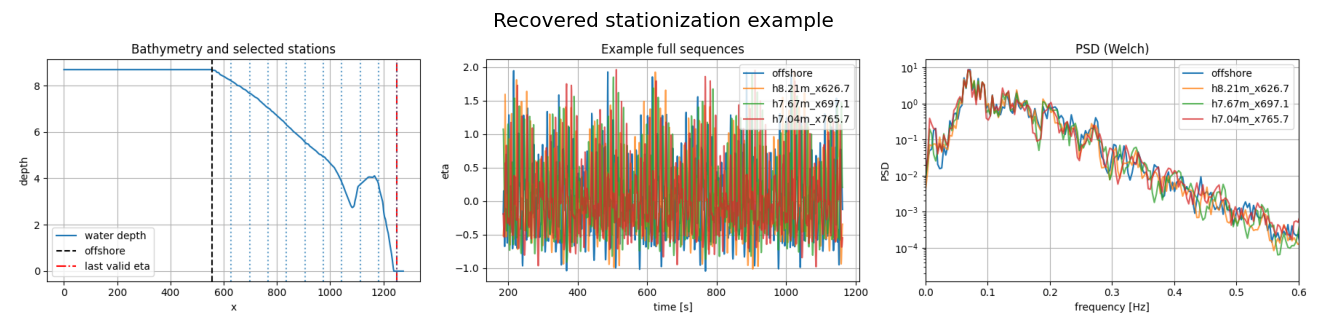

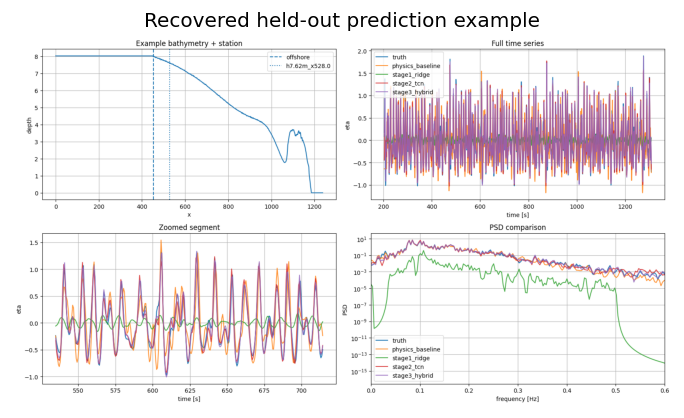

In [15]:
# =========================
# Recover and display representative saved figures from the ready notebook
# =========================
recovered_figures = {}

figure_specs = {
    "example_stationization_from_ready_notebook": (9, 0),
    "stage2_training_history_from_ready_notebook": (16, 0),
    "stage3_training_history_from_ready_notebook": (18, 0),
    "test_comparison_summary_from_ready_notebook": (20, 0),
    "example_test_station_predictions_from_ready_notebook": (20, 1),
}

for name, (cell_idx, display_order) in figure_specs.items():
    out_path = OUTPUT_FIG_ROOT / f"{name}.png"
    saved = save_embedded_png(ready_nb, cell_idx, display_order, out_path)
    if saved is not None:
        recovered_figures[name] = saved

print("Recovered figures:")
for k, v in recovered_figures.items():
    print(f"- {k}: {v}")

# Display the two most useful presentation/report figures
if "example_stationization_from_ready_notebook" in recovered_figures:
    render_png(recovered_figures["example_stationization_from_ready_notebook"], title="Recovered stationization example", figsize=(14, 4))

if "example_test_station_predictions_from_ready_notebook" in recovered_figures:
    render_png(recovered_figures["example_test_station_predictions_from_ready_notebook"], title="Recovered held-out prediction example", figsize=(14, 4))


In [16]:
# =========================
# Report-ready narrative notes
# =========================
summary_df = clean_dataframe(tables.get("summary_df"))
notes = {}

if isinstance(summary_df, pd.DataFrame):
    stage2_row = summary_df.loc[summary_df["model"] == "stage2_tcn"]
    stage3_row = summary_df.loc[summary_df["model"] == "stage3_hybrid"]
    physics_row = summary_df.loc[summary_df["model"] == "physics_baseline"]

    if len(stage2_row) and len(stage3_row) and len(physics_row):
        stage2_row = stage2_row.iloc[0]
        stage3_row = stage3_row.iloc[0]
        physics_row = physics_row.iloc[0]

        rmse_impr_vs_stage2 = 100.0 * (stage2_row["rmse"] - stage3_row["rmse"]) / abs(stage2_row["rmse"])
        lag_impr_vs_stage2 = 100.0 * (stage2_row["lag_abs_seconds"] - stage3_row["lag_abs_seconds"]) / abs(stage2_row["lag_abs_seconds"])
        ig_impr_vs_stage2 = 100.0 * (stage2_row["band_rel_err_0"] - stage3_row["band_rel_err_0"]) / abs(stage2_row["band_rel_err_0"])
        ss_impr_vs_stage2 = 100.0 * (stage2_row["band_rel_err_1"] - stage3_row["band_rel_err_1"]) / abs(stage2_row["band_rel_err_1"])
        rmse_impr_vs_phys = 100.0 * (physics_row["rmse"] - stage3_row["rmse"]) / abs(physics_row["rmse"])

        notes["abstract_results"] = (
            f"On the held-out test set, the physics-informed hybrid achieved the lowest mean RMSE "
            f"({stage3_row['rmse']:.3f}), the lowest MAE ({stage3_row['mae']:.3f}), the highest correlation "
            f"({stage3_row['corr']:.3f}), and the lowest mean absolute timing error ({stage3_row['lag_abs_seconds']:.3f} s). "
            f"Relative to the Stage 2 TCN, this corresponds to a {rmse_impr_vs_stage2:.1f}% RMSE reduction and a "
            f"{lag_impr_vs_stage2:.1f}% reduction in timing error. Relative to the deterministic physics baseline, "
            f"the RMSE reduction was {rmse_impr_vs_phys:.1f}%."
        )

        notes["results_interpretation"] = (
            f"The Stage 3 model outperformed the pure TCN on RMSE, MAE, correlation, timing error, and both spectral-band "
            f"energy-error metrics, including a {ig_impr_vs_stage2:.1f}% reduction in infragravity-band relative error and a "
            f"{ss_impr_vs_stage2:.1f}% reduction in sea-swell-band relative error. "
            f"However, the mean sample-wise R² remained lower for Stage 3 ({stage3_row['r2']:.3f}) than for Stage 2 "
            f"({stage2_row['r2']:.3f}), which suggests that a smaller number of difficult edge cases still create large "
            f"variance-normalized misses even though the overall waveform agreement is substantially better."
        )

if len(stage2_history_df):
    s2_best = stage2_history_df.loc[stage2_history_df['val_total'].idxmin()]
    notes["stage2_training"] = (
        f"The Stage 2 TCN was trained for {int(stage2_history_df['epoch'].max())} epochs, with the best validation loss "
        f"({s2_best['val_total']:.4f}) reached at epoch {int(s2_best['epoch'])}. "
        f"The training and validation curves both decreased over time, suggesting useful learning without catastrophic divergence."
    )

if len(stage3_history_df):
    s3_best = stage3_history_df.loc[stage3_history_df['val_total'].idxmin()]
    notes["stage3_training"] = (
        f"The Stage 3 hybrid was trained for {int(stage3_history_df['epoch'].max())} epochs, with the best validation loss "
        f"({s3_best['val_total']:.4f}) reached at epoch {int(s3_best['epoch'])}. "
        f"Its validation curve remained consistently below the early-epoch values and finished well below the Stage 2 best value, "
        f"supporting the claim that the added physics-informed representation improved optimization and generalization."
    )

if isinstance(dataset_overview_df, pd.DataFrame):
    note_bits = []
    lookup = dict(zip(dataset_overview_df["metric"], dataset_overview_df["value"]))
    if "Selected runs" in lookup and "Total station samples" in lookup:
        note_bits.append(f"The final modeling dataset contained {int(lookup['Selected runs']):,} processed runs and {int(lookup['Total station samples']):,} station-level samples.")
    if "Median target depth [m]" in lookup:
        note_bits.append(f"The median target-station depth was {lookup['Median target depth [m]']:.2f} m.")
    if "Median sequence length [samples]" in lookup:
        note_bits.append(f"The median sequence length was {lookup['Median sequence length [samples]']:.0f} samples.")
    notes["data_summary"] = " ".join(note_bits)

if isinstance(depth_summary_df, pd.DataFrame):
    depth_stage3 = depth_summary_df.loc[depth_summary_df["model"] == "stage3_hybrid"].copy()
    if len(depth_stage3):
        shallow = depth_stage3.loc[depth_stage3["depth_bin"].astype(str) == "<=1m"]
        deep = depth_stage3.loc[depth_stage3["depth_bin"].astype(str) == ">6m"]
        if len(shallow) and len(deep):
            shallow = shallow.iloc[0]
            deep = deep.iloc[0]
            notes["depth_regime_note"] = (
                f"Depth-wise evaluation shows that Stage 3 performs best in deeper stations, where RMSE fell to {deep['rmse']:.3f} "
                f"and correlation rose to {deep['corr']:.3f} for depths greater than 6 m. The shallowest stations (<=1 m) remained "
                f"the hardest regime, with RMSE {shallow['rmse']:.3f} and a strongly degraded R², making shallow-water edge cases "
                f"the clearest target for future work."
            )

notes_path = OUTPUT_NOTE_ROOT / "report_ready_notes.md"
with notes_path.open("w", encoding="utf-8") as f:
    f.write("# Report-ready notes\n\n")
    for key, value in notes.items():
        f.write(f"## {key}\n\n{value}\n\n")

for key, value in notes.items():
    display(Markdown(f"### {key}\n\n{value}"))

print("Saved notes to:", notes_path)


### abstract_results

On the held-out test set, the physics-informed hybrid achieved the lowest mean RMSE (0.086), the lowest MAE (0.065), the highest correlation (0.891), and the lowest mean absolute timing error (0.231 s). Relative to the Stage 2 TCN, this corresponds to a 38.2% RMSE reduction and a 76.6% reduction in timing error. Relative to the deterministic physics baseline, the RMSE reduction was 79.6%.

### results_interpretation

The Stage 3 model outperformed the pure TCN on RMSE, MAE, correlation, timing error, and both spectral-band energy-error metrics, including a 34.8% reduction in infragravity-band relative error and a 58.1% reduction in sea-swell-band relative error. However, the mean sample-wise R² remained lower for Stage 3 (-1.969) than for Stage 2 (-1.399), which suggests that a smaller number of difficult edge cases still create large variance-normalized misses even though the overall waveform agreement is substantially better.

### stage2_training

The Stage 2 TCN was trained for 20 epochs, with the best validation loss (0.2362) reached at epoch 15. The training and validation curves both decreased over time, suggesting useful learning without catastrophic divergence.

### stage3_training

The Stage 3 hybrid was trained for 25 epochs, with the best validation loss (0.1137) reached at epoch 23. Its validation curve remained consistently below the early-epoch values and finished well below the Stage 2 best value, supporting the claim that the added physics-informed representation improved optimization and generalization.

### data_summary

The final modeling dataset contained 5,000 processed runs and 50,000 station-level samples. The median target-station depth was 4.76 m. The median sequence length was 1755 samples.

### depth_regime_note

Depth-wise evaluation shows that Stage 3 performs best in deeper stations, where RMSE fell to 0.062 and correlation rose to 0.961 for depths greater than 6 m. The shallowest stations (<=1 m) remained the hardest regime, with RMSE 0.106 and a strongly degraded R², making shallow-water edge cases the clearest target for future work.

Saved notes to: funwave_capstone_report_support_outputs\notes\report_ready_notes.md


In [17]:
# =========================
# Asset index
# =========================
asset_rows = []
for subdir in [OUTPUT_TABLE_ROOT, OUTPUT_FIG_ROOT, OUTPUT_NOTE_ROOT]:
    for path in sorted(subdir.glob("*")):
        asset_rows.append({
            "category": subdir.name,
            "file_name": path.name,
            "relative_path": str(path),
            "size_kb": round(path.stat().st_size / 1024.0, 2),
        })

asset_index_df = pd.DataFrame(asset_rows).sort_values(["category", "file_name"]).reset_index(drop=True)
display(asset_index_df)
asset_index_df.to_csv(OUTPUT_TABLE_ROOT / "report_support_asset_index.csv", index=False)


,category,file_name,relative_path,size_kb
0,figures,dataset_overview_summary_table.png,funwave_capstone_report_support_outputs\figure...,90.73
1,figures,depth_bin_performance_curves.png,funwave_capstone_report_support_outputs\figure...,145.46
2,figures,eda_feature_distributions.png,funwave_capstone_report_support_outputs\figure...,128.93
3,figures,eda_hs_vs_tp_scatter.png,funwave_capstone_report_support_outputs\figure...,79.97
4,figures,example_stationization_from_ready_notebook.png,funwave_capstone_report_support_outputs\figure...,218.70
5,figures,example_test_station_predictions_from_ready_no...,funwave_capstone_report_support_outputs\figure...,379.48
6,figures,heldout_model_comparison_compact.png,funwave_capstone_report_support_outputs\figure...,99.49
7,figures,heldout_model_comparison_table.png,funwave_capstone_report_support_outputs\figure...,56.57
8,figures,metric_glossary_table.png,funwave_capstone_report_support_outputs\figure...,86.01
9,figures,model_training_configuration_table.png,funwave_capstone_report_support_outputs\figure...,80.04
